# Glove Gesture ML Explorer

Configurable pipeline for exploring hand gesture recognition from the sensory glove dataset.

**Workflow:**
1. [Config](#1-configuration) — Set data path, select columns, labels, and splits
2. [Load Data](#2-data-loading) — Read CSVs, attach labels from folder names
3. [Preprocess](#3-preprocessing) — Filter, normalise, extract features
4. [Train & Evaluate](#4-training--evaluation) — Run selected ML algorithms
5. [Results](#5-results-comparison) — Compare algorithms side-by-side

---
**Dataset structure:**  
Each folder under `DATA_ROOT` is a gesture label (e.g. `TwoHand_L_Fist_R_Fist`).  
Each CSV = one 5-second trial at ~22 Hz → ~110 rows × 295 columns.

> **Note on `TwoHand_L_Flat_R_Flat`:** Files in this folder are named `*L_Fist_R_Fist*` by mistake — they are Flat gestures. The label is taken from the **folder name**, not the filename, so this is handled correctly automatically.

---
## 0. Install / Import Dependencies

In [1]:
# Run once to install any missing packages
# %load_ext cuml.accel
# import cuml.accel
# cuml.accel.install()

import subprocess, sys
pkgs = ['scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + pkgs)
print('Dependencies ready.')

Dependencies ready.


In [2]:
import os, glob, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as scipy_signal
from scipy.stats import skew, kurtosis
# from zipfile import Path
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, StratifiedGroupKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

# Classifiers
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import VotingClassifier, StackingClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
print('Imports OK.')


# from cuml.accel import is_proxy
# NoteUsed = RandomForestClassifier(n_estimators=50, random_state=0)
# print("cuML accel installed OK")
# print("RandomForest accelerated via cuML:", is_proxy(NoteUsed))

Imports OK.


---
## 1. Configuration

**Edit this cell to control the entire pipeline.**

In [3]:
# =============================================================================
# 1A. DATA PATHS
# =============================================================================
# You can include data from MULTIPLE users / source folders.
#
# Each entry in DATA_PATHS is a folder that DIRECTLY contains gesture-label
# subfolders (e.g. .../Alan/Static, .../Bridgette/Dynamic).
# All matching label folders across these paths are merged by label name,
# so e.g. Alan/Static/Double_Okay and Bridgette/Static/Double_Okay end up
# in the same "Double_Okay" class.
#
# Tip: comment out a path to exclude that user from training without deleting it.


DATA_PATHS = [
    # # '/home/jestin/ThesisRepo/ML/NewTrainingData/Static',
    # '/home/jestin/ThesisRepo/ML/NewTestData/1_Alan/Static',
    # '/home/jestin/ThesisRepo/ML/NewTestData/2_Alex/Static',
    # '/home/jestin/ThesisRepo/ML/NewTestData/3_Anghad/Static',
    # '/home/jestin/ThesisRepo/ML/NewTestData/4_Daniel/Static',
    # '/home/jestin/ThesisRepo/ML/NewTestData/5_Georgia/Static',
    # '/home/jestin/ThesisRepo/ML/NewTestData/6_Harry/Static',
    # '/home/jestin/ThesisRepo/ML/NewTestData/7_Henry/Static',
    # '/home/jestin/ThesisRepo/ML/NewTestData/8_Jestin/Static',
    # '/home/jestin/ThesisRepo/ML/NewTestData/9_Joselyn/Static',
    # '/home/jestin/ThesisRepo/ML/NewTestData/10_Josh/Static',
    # '/home/jestin/ThesisRepo/ML/NewTestData/11_Mansh/Static',
    # '/home/jestin/ThesisRepo/ML/NewTestData/12_Marcus/Static',
    # '/home/jestin/ThesisRepo/ML/NewTestData/13_Nat/Static',
    # '/home/jestin/ThesisRepo/ML/NewTestData/14_StephenV2/Static',
    # # '/home/jestin/ThesisRepo/ML/NewTestData/15_Tash/Static',
    # '/home/jestin/ThesisRepo/ML/NewTestData/16_Bella/Static',
    # '/home/jestin/ThesisRepo/ML/NewTestData/17_Raquel/Static',


    # '/home/jestin/ThesisRepo/ML/NewTrainingData/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/1_Alan/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/2_Alex/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/3_Anghad/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/4_Daniel/Dynamic',
    # '/home/jestin/ThesisRepo/ML/NewTestData/5_Georgia/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/6_Harry/Dynamic',
    # '/home/jestin/ThesisRepo/ML/NewTestData/7_Henry/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/8_Jestin/Dynamic',
    # '/home/jestin/ThesisRepo/ML/NewTestData/9_Joselyn/Dynamic',
    # '/home/jestin/ThesisRepo/ML/NewTestData/10_Josh/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/11_Mansh/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/12_Marcus/Dynamic',
    # '/home/jestin/ThesisRepo/ML/NewTestData/13_Nat/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/14_StephenV2/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/15_Tash/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/16_Bella/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/17_Raquel/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/18_Bridgette/Dynamic'
]



# Backwards-compat shortcut: if you prefer the old single-folder workflow,
# set DATA_ROOT to a string and leave DATA_PATHS = None (or empty).
# Example:
#   DATA_ROOT  = '/home/jestin/ThesisRepo/ML/NewTrainingData/Static'
#   DATA_PATHS = None
DATA_ROOT = None

# Labels to INCLUDE. Set to None to use ALL gesture subfolders found.
# Example: INCLUDE_LABELS = ['Double_Closed_Fist', 'Double_Open_Palm']
# INCLUDE_LABELS = [
#     'Double_Closed_Fist', 
#     # 'Double_Nothing', 
#     'Double_Okay', 
#     'Double_Open_Palm',
#     'Double_Phone', 
#     'Double_Pistol', 
#     'Double_Spiderman'
# ]

INCLUDE_LABELS = None  # None = include all labels found in the data paths


# =============================================================================
# 1B. COLUMN SELECTION
# =============================================================================
# Choose which sensor modalities to include.
# Each flag independently includes/excludes that group of columns.

USE_YAW_PITCH_ROLL   = True    # IMU Euler angles (yaw, pitch, roll / heading)
USE_QUATERNIONS      = False   # Raw quaternion components (quat_w/x/y/z)
                               # Note: for TwoHand_L_Flat_R_Flat, quaternions are
                               #       the primary data — pitch/roll/yaw are derived.
                               #       Set True if using that label.
USE_ACCELEROMETER    = True    # Linear accelerometer (ax, ay, az)
USE_FLEX_SENSORS     = True    # Flex sensor readings (mcp_flex, pip_flex)

# Choose which body segments to include.
# Available: 'palm_prox', 'thumb', 'index', 'middle', 'ring', 'pinky', 'wrist'
# 'palm_mid'  = excluded — IMU columns exist in CSV but contain no sensor data
# 'palm_prox' = IMU on back of palm (proximal, near wrist)
# 'wrist'     = IMU at end of forearm closest to wrist
# Note: flex sensors exist for fingers only (thumb, index, middle, ring, pinky) — NOT palm
INCLUDE_SEGMENTS = [
    'palm_mid',  
    # 'palm_prox', # excluded: IMU columns exist but contain no data
    'thumb',
    'index',
    'middle',
    'ring',
    'pinky',
    'wrist',
]

# Choose which hands to include
INCLUDE_HANDS = ['left', 'right']  # options: 'left', 'right', or both

# =============================================================================
# 1C. PREPROCESSING
# =============================================================================

# --- Resampling ---
# Resample each trial to a fixed number of time steps (handles variable-length files).
# Set to None to skip resampling (all files must then have the same row count).
RESAMPLE_TO_N_STEPS = 90      # target number of rows per trial

# --- Low-pass Butterworth filter ---
APPLY_BUTTERWORTH    = True     # Apply low-pass filter to smooth IMU noise
BUTTERWORTH_CUTOFF   = 10.0      # Cutoff frequency in Hz
BUTTERWORTH_ORDER    = 4        # Filter order
SAMPLING_RATE_HZ     = 30.0     # Approximate sampling rate of the glove

# --- Data augmentation ---
APPLY_AUGMENTATION = True
N_AUG_PER_TRAIN_TRIAL = 2
AUG_USE_JITTER = False      # <--- new flag
AUG_JITTER_SIGMA = 0.01
AUG_USE_SCALE = True
AUG_SCALE_RANGE = (0.9, 1.1)
AUG_USE_TIME_WARP = False 
AUG_WARP_RANGE = (0.9, 1.1)


# --- Normalisation ---
# 'standard'  → zero mean, unit variance (StandardScaler) — good for SVM, LDA
# 'minmax'    → scale to [0, 1]  (MinMaxScaler) — good for KNN, neural nets
# None        → no normalisation
NORMALISATION = 'minmax'

# --- Feature extraction mode ---
# 'flatten'    → use the raw resampled time series as a flat feature vector
#                (n_steps × n_channels features per sample)
# 'stats'      → extract statistical features per channel
#                (mean, std, min, max, range, RMS, skew, kurtosis)
# 'fft'        → FFT magnitude spectrum per channel
# 'stats+fft'  → combine statistical + FFT features
FEATURE_MODE = 'stats+fft'    # Recommended starting point

# =============================================================================
# 1D. EVALUATION (true LOUO — every user held out once)
# =============================================================================
RANDOM_STATE     = 42     # seeds classifiers and t-SNE for reproducibility

# =============================================================================
# 1E. ALGORITHMS
# =============================================================================
# Set True/False to include/exclude each algorithm.
ALGORITHMS = {
    'SVM (RBF)'           : True,
    'SVM (Linear)'        : True,
    'Random Forest'       : True,
    'KNN'                 : True,
    'Gradient Boosting'   : False,   # Slower — enable when needed
    'Logistic Regression' : True,
    'LDA'                 : True,
    "Voting Soft (SVM+RF+LogReg)" : True,
    "Stacking (SVM+RF+LogReg)" : True,
}



# Resolve active data paths (supports both DATA_PATHS list and legacy DATA_ROOT)
ACTIVE_DATA_PATHS = []
if DATA_PATHS:
    ACTIVE_DATA_PATHS = [p for p in DATA_PATHS if p and not p.strip().startswith('#')]
if not ACTIVE_DATA_PATHS and DATA_ROOT:
    ACTIVE_DATA_PATHS = [DATA_ROOT]

print('Configuration loaded.')
print(f'  Data paths ({len(ACTIVE_DATA_PATHS)}):')
for p in ACTIVE_DATA_PATHS:
    print(f'    - {p}')
print(f'  Hands      : {INCLUDE_HANDS}')
print(f'  Segments   : {INCLUDE_SEGMENTS}')
print(f'  Modalities : YPR={USE_YAW_PITCH_ROLL}, Quat={USE_QUATERNIONS}, Accel={USE_ACCELEROMETER}, Flex={USE_FLEX_SENSORS}')
print(f'  Features   : {FEATURE_MODE}')
print(f'  Algorithms : {[k for k,v in ALGORITHMS.items() if v]}')


REPORT_OUTPUT_DIR = Path('/home/jestin/ThesisRepo/ML/NewReports/StaticReports') # Directory to save PDF reports
REPORT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =============================================================================
# 1B. LEAVE-ONE-USER-OUT (LOUO) VALIDATION
# =============================================================================
# Cross-validation in this notebook is performed user-by-user rather than
# by random trial shuffling. Every LOUO fold holds out one user entirely
# (none of their trials are in train OR CV), trains on the rest, and scores
# on that user. `cv_mean / cv_std` in the results table = mean ± std accuracy
# across these per-user folds.
#
# To exclude a user entirely (not train, not validate, not test), just
# comment that user out of DATA_PATHS above.

# =============================================================================
# 1C. COMPLETION NOTIFICATIONS
# =============================================================================
# LOUO can take a while. The final cell (Section 11) fires whichever channels
# you enable here, so you can walk away during the run.
#   NOTIFY_DESKTOP → Ubuntu toast via `notify-send` (needs `libnotify-bin`,
#                    pre-installed on most desktops).
#   NOTIFY_BEEP    → short system bell from inside the notebook.
#   NOTIFY_PUSH    → off-device push via https://ntfy.sh (free, no signup).
#                    Install the ntfy app on your phone, subscribe to
#                    NOTIFY_NTFY_TOPIC, and you'll get a push when the run
#                    finishes. The topic acts like a password — pick a long,
#                    hard-to-guess string.
NOTIFY_DESKTOP    = True
NOTIFY_BEEP       = False
NOTIFY_PUSH       = False   # set to True after picking a topic below
NOTIFY_NTFY_TOPIC = 'jestin-thesis-louo-CHANGE-ME-to-something-unique'



Configuration loaded.
  Data paths (13):
    - /home/jestin/ThesisRepo/ML/NewTestData/1_Alan/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/2_Alex/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/3_Anghad/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/4_Daniel/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/6_Harry/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/8_Jestin/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/11_Mansh/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/12_Marcus/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/14_StephenV2/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/15_Tash/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/16_Bella/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/17_Raquel/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/18_Bridgette/Dynamic
  Hands      : ['left', 'right']
  Segments   : ['palm_mid', 'thumb', 'index', 'middle', 'ring', 'pinky', 'wrist']
  Modalities : YPR=True, Quat=Fals

---
## 2. Data Loading

In [4]:
# ── Build column selector from config ─────────────────────────────────────────

# All 295 columns, grouped by type for easy selection
META_COLS = [
    'run_index', 'request_id', 'request_ts',
    'right_recv_time_ms', 'right_glove_time_ms', 'right_time',
    'left_recv_time_ms',  'left_glove_time_ms',  'left_time',
    'left_hand', 'right_hand'
]

SEGMENTS_WITH_FLEX = ['thumb', 'index', 'middle', 'ring', 'pinky']  # palm has no flex sensors
IMU_LOCATIONS = ['mid', 'prox']  # distal phalanx / proximal phalanx

def build_sensor_columns(hands, segments, use_ypr, use_quat, use_accel, use_flex):
    """Return list of sensor column names matching the user config."""
    cols = []
    for hand in hands:
        for seg in segments:
            # Determine IMU sub-locations for this segment
            # palm has mid + prox; all finger segments have mid + prox; wrist has no sub-location
            if seg == 'wrist':
                prefix = f'{hand}_wrist'
                if use_ypr:
                    cols += [f'{prefix}_heading', f'{prefix}_pitch', f'{prefix}_roll']
                if use_quat:
                    cols += [f'{prefix}_quat_w', f'{prefix}_quat_x',
                             f'{prefix}_quat_y', f'{prefix}_quat_z']
                if use_accel:
                    cols += [f'{prefix}_ax', f'{prefix}_ay', f'{prefix}_az']
                # wrist has no flex sensor
            else:
                # segment has mid + prox IMU positions
                # For 'thumb','index' etc, map to e.g. 'left_thumb_mid_yaw'
                for loc in ['mid', 'prox']:
                    prefix = f'{hand}_{seg}_{loc}'
                    if use_ypr:
                        cols += [f'{prefix}_yaw', f'{prefix}_pitch', f'{prefix}_roll']
                    if use_quat:
                        cols += [f'{prefix}_quat_w', f'{prefix}_quat_x',
                                 f'{prefix}_quat_y', f'{prefix}_quat_z']
                    if use_accel:
                        cols += [f'{prefix}_ax', f'{prefix}_ay', f'{prefix}_az']
                # Flex sensors (one per finger joint combination, not per loc)
                if use_flex and seg in ['thumb', 'index', 'middle', 'ring', 'pinky']:  # palm has no flex
                    cols += [f'{hand}_{seg}_mcp_flex', f'{hand}_{seg}_pip_flex']
    return cols

# Map user-friendly segment names to CSV naming convention
seg_map = {
    'palm_mid':  'palm',   # excluded by default — no sensor data on palm_mid
    # 'palm_prox': 'palm',   # deduplicated below
    'thumb':     'thumb',
    'index':     'index',
    'middle':    'middle',
    'ring':      'ring',
    'pinky':     'pinky',
    'wrist':     'wrist',
}

# Resolve segments, de-duplicating palm if both palm_mid and palm_prox selected
resolved_segs = list(dict.fromkeys([seg_map[s] for s in INCLUDE_SEGMENTS]))

SENSOR_COLS = build_sensor_columns(
    hands    = INCLUDE_HANDS,
    segments = resolved_segs,
    use_ypr  = USE_YAW_PITCH_ROLL,
    use_quat = USE_QUATERNIONS,
    use_accel= USE_ACCELEROMETER,
    use_flex = USE_FLEX_SENSORS
)

print(f'Selected {len(SENSOR_COLS)} sensor columns.')
print('First 10:', SENSOR_COLS[:10])
print('Last 10:', SENSOR_COLS[-10:])

Selected 176 sensor columns.
First 10: ['left_palm_mid_yaw', 'left_palm_mid_pitch', 'left_palm_mid_roll', 'left_palm_mid_ax', 'left_palm_mid_ay', 'left_palm_mid_az', 'left_palm_prox_yaw', 'left_palm_prox_pitch', 'left_palm_prox_roll', 'left_palm_prox_ax']
Last 10: ['right_pinky_prox_ay', 'right_pinky_prox_az', 'right_pinky_mcp_flex', 'right_pinky_pip_flex', 'right_wrist_heading', 'right_wrist_pitch', 'right_wrist_roll', 'right_wrist_ax', 'right_wrist_ay', 'right_wrist_az']


In [5]:
# ── Load all CSV files from one or more user folders ─────────────────────────

def load_dataset(data_paths, include_labels, sensor_cols):
    """
    Load all CSVs from gesture-label subfolders found inside each path in
    `data_paths`. Trials from the same label across different source folders
    are merged into a single class.

    Returns:
        trials      : list of np.ndarray (per-trial sensor matrices)
        labels      : list of class label strings
        class_names : sorted list of unique class labels
        source_info : list of source folder paths per trial (for traceability)
    """
    if isinstance(data_paths, str):
        data_paths = [data_paths]
    if not data_paths:
        raise ValueError('No data paths provided. Set DATA_PATHS or DATA_ROOT.')

    # Validate each path exists
    resolved_paths = []
    for p in data_paths:
        p_exp = os.path.expanduser(p)
        if not os.path.isdir(p_exp):
            raise FileNotFoundError(
                f"Data path not found: '{p_exp}'\n"
                "Update DATA_PATHS in the Configuration cell."
            )
        resolved_paths.append(p_exp)

    # Discover label subfolders within each path, merging by label name
    SKIP = {'PDF', 'sdb', 'idk'}
    label_to_folders = {}   # label -> list of full folder paths
    for root in resolved_paths:
        for d in sorted(os.listdir(root)):
            full = os.path.join(root, d)
            if not os.path.isdir(full) or d in SKIP:
                continue
            label_to_folders.setdefault(d, []).append(full)

    if include_labels is not None:
        label_to_folders = {k: v for k, v in label_to_folders.items()
                            if k in include_labels}

    if not label_to_folders:
        raise ValueError('No label folders found. Check DATA_PATHS and INCLUDE_LABELS.')

    label_names = sorted(label_to_folders.keys())
    print(f'Found {len(label_names)} gesture classes across {len(resolved_paths)} source folder(s):')

    trials, labels, source_info = [], [], []
    for label in label_names:
        folders = label_to_folders[label]
        per_source_counts = []
        for folder in folders:
            csv_files = sorted(glob.glob(os.path.join(folder, '*.csv')))
            per_source_counts.append((folder, len(csv_files)))
            for fpath in csv_files:
                try:
                    df = pd.read_csv(fpath)
                    available = [c for c in sensor_cols if c in df.columns]
                    if not available:
                        print(f'    WARNING: no matching sensor columns in {os.path.basename(fpath)}')
                        continue
                    trials.append(df[available].values.astype(np.float32))
                    labels.append(label)
                    source_info.append(folder)
                except Exception as e:
                    print(f'    ERROR loading {os.path.basename(fpath)}: {e}')
        total = sum(c for _, c in per_source_counts)
        print(f'  [{label}]  →  {total} files'
              + (' from ' + ', '.join(f"{os.path.basename(os.path.dirname(fp))}({n})"
                                       for fp, n in per_source_counts)
                 if len(per_source_counts) > 1 else ''))

    print(f'\nTotal trials loaded: {len(trials)}')
    return trials, labels, label_names, source_info


trials_raw, labels_raw, class_names, source_info = load_dataset(
    ACTIVE_DATA_PATHS, INCLUDE_LABELS, SENSOR_COLS
)

# Class distribution
from collections import Counter
print('\nClass distribution:')
for cls, cnt in sorted(Counter(labels_raw).items()):
    print(f'  {cls}: {cnt} trials')

# Per-source-folder distribution (helpful for spotting imbalance across users)
print('\nTrials per source folder:')
for src, cnt in sorted(Counter(source_info).items()):
    # Show a friendly tag like "Alan/Static" instead of a long path
    tag = os.sep.join(src.split(os.sep)[-2:])
    print(f'  {tag}: {cnt} trials')

# ── Derive a per-trial USER id from source folder path ───────────────────
# Each entry in source_info is the full folder of a label, e.g.
#   /home/jestin/ThesisRepo/ML/NewTestData/8_Jestin/Dynamic/Double_Lower
# The "user" is the parent of the parent of that folder (here: 8_Jestin).
def _user_from_source(p):
    return os.path.basename(os.path.dirname(os.path.dirname(p)))

users_raw = [_user_from_source(p) for p in source_info]
unique_users = sorted(set(users_raw))
print(f'\nUsers detected: {len(unique_users)} → {unique_users}')


Found 7 gesture classes across 13 source folder(s):
  [Double_Lower]  →  65 files from Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5)
  [Double_Nothing]  →  62 files from Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(0), Dynamic(5), Dynamic(5), Dynamic(6), Dynamic(5), Dynamic(6), Dynamic(5), Dynamic(5)
  [Double_Pistol_Recoil]  →  65 files from Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5)
  [Double_Raise]  →  65 files from Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5)
  [Double_Wiggle]  →  64 files from Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(4), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5)

---
## 3. Preprocessing

In [6]:
# ── Step 1: Resample to fixed length ──────────────────────────────────────────

def resample_trial(trial, n_steps):
    """Resample a (T, C) array to (n_steps, C) using linear interpolation."""
    T, C = trial.shape
    if T == n_steps:
        return trial
    old_idx = np.linspace(0, 1, T)
    new_idx = np.linspace(0, 1, n_steps)
    resampled = np.zeros((n_steps, C), dtype=np.float32)
    for c in range(C):
        resampled[:, c] = np.interp(new_idx, old_idx, trial[:, c])
    return resampled

if RESAMPLE_TO_N_STEPS is not None:
    trials_resampled = [resample_trial(t, RESAMPLE_TO_N_STEPS) for t in trials_raw]
    print(f'Resampled all trials to {RESAMPLE_TO_N_STEPS} time steps.')
else:
    trials_resampled = trials_raw
    lengths = [t.shape[0] for t in trials_resampled]
    print(f'No resampling. Trial lengths: min={min(lengths)}, max={max(lengths)}, mean={np.mean(lengths):.1f}')
    if min(lengths) != max(lengths):
        print('  WARNING: Variable-length trials detected. Enable RESAMPLE_TO_N_STEPS '
              'or use a feature extraction mode that handles variable length.')

print(f'Trial shape: {trials_resampled[0].shape}  (time_steps × channels)')

Resampled all trials to 90 time steps.
Trial shape: (90, 176)  (time_steps × channels)


In [7]:
# ── Step 2: Butterworth low-pass filter ───────────────────────────────────────

def apply_butterworth(trials, cutoff, order, fs):
    """Apply a zero-phase Butterworth low-pass filter to each channel of each trial."""
    nyq = fs / 2.0
    norm_cutoff = cutoff / nyq
    if norm_cutoff >= 1.0:
        print(f'  WARNING: cutoff {cutoff} Hz >= Nyquist {nyq} Hz — skipping filter.')
        return trials
    b, a = scipy_signal.butter(order, norm_cutoff, btype='low', analog=False)
    filtered = []
    for t in trials:
        t_filt = scipy_signal.filtfilt(b, a, t, axis=0).astype(np.float32)
        filtered.append(t_filt)
    return filtered

if APPLY_BUTTERWORTH:
    trials_filtered = apply_butterworth(
        trials_resampled, BUTTERWORTH_CUTOFF, BUTTERWORTH_ORDER, SAMPLING_RATE_HZ
    )
    print(f'Applied Butterworth low-pass filter: {BUTTERWORTH_CUTOFF} Hz cutoff, '
          f'order {BUTTERWORTH_ORDER}, Nyquist = {SAMPLING_RATE_HZ/2} Hz')
else:
    trials_filtered = trials_resampled
    print('Butterworth filter skipped.')

Applied Butterworth low-pass filter: 10.0 Hz cutoff, order 4, Nyquist = 15.0 Hz


In [8]:
# 2b. Time-series augmentation helpers (operate on trials_filtered)

def jitter_trial(trial, sigma=0.01):
    """Add Gaussian noise to a (T, C) trial."""
    noise = np.random.normal(0, sigma, size=trial.shape).astype(np.float32)
    return (trial + noise).astype(np.float32)


def scale_trial(trial, scale_range=(0.9, 1.1)):
    """Global amplitude scaling for a (T, C) trial."""
    scale = np.float32(np.random.uniform(scale_range[0], scale_range[1]))
    return (trial * scale).astype(np.float32)


def time_warp_trial(trial, warp_range=(0.9, 1.1), n_steps=None):
    """
    Simple time warping: resample to a different length then back to n_steps.
    If n_steps is None, preserve current length.
    """
    factor = np.random.uniform(*warp_range)
    T, C = trial.shape
    warped_len = max(5, int(T * factor))

    old_idx = np.linspace(0, 1, T)
    mid_idx = np.linspace(0, 1, warped_len)
    warped = np.zeros((warped_len, C), dtype=np.float32)
    for c in range(C):
        warped[:, c] = np.interp(mid_idx, old_idx, trial[:, c])

    if n_steps is not None and warped_len != n_steps:
        return resample_trial(warped, n_steps)
    return warped


def augment_trials(trials, labels,
                   n_aug_per_trial=1,
                   use_jitter=True,
                   jitter_sigma=0.01,
                   use_scale=True,
                   scale_range=(0.9, 1.1),
                   use_time_warp=False,
                   warp_range=(0.9, 1.1),
                   n_steps=None):
    """
    Apply time-series augmentation to a list of (T, C) trials and labels.
    Returns new_trials, new_labels.
    """
    aug_trials = []
    aug_labels = []

    for trial, label in zip(trials, labels):
        # keep original
        aug_trials.append(trial.astype(np.float32))
        aug_labels.append(label)

        for _ in range(n_aug_per_trial):
            t_aug = trial.astype(np.float32)

            if use_jitter:
                t_aug = jitter_trial(t_aug, sigma=jitter_sigma)
            if use_scale:
                t_aug = scale_trial(t_aug, scale_range=scale_range)
            if use_time_warp:
                t_aug = time_warp_trial(t_aug, warp_range=warp_range, n_steps=n_steps)

            aug_trials.append(t_aug)
            aug_labels.append(label)

    return aug_trials, aug_labels

In [9]:
# 3. Feature extraction + train/test split + train-only augmentation

# --- Existing feature functions (unchanged) ---

def extract_stats(trial):
    feats = np.concatenate([
        trial.mean(axis=0),
        trial.std(axis=0),
        trial.min(axis=0),
        trial.max(axis=0),
        trial.max(axis=0) - trial.min(axis=0),
        np.sqrt((trial ** 2).mean(axis=0)),
        skew(trial, axis=0).astype(np.float32),
        kurtosis(trial, axis=0).astype(np.float32),
    ])
    return feats


def extract_fft(trial, fs):
    n = trial.shape[0]
    fftmag = np.abs(np.fft.rfft(trial, axis=0))
    return fftmag.flatten().astype(np.float32)


def extract_features(trials, mode, fs):
    X = []
    for t in trials:
        if mode == "flatten":
            feats = t.flatten()
        elif mode == "stats":
            feats = extract_stats(t)
        elif mode == "fft":
            feats = extract_fft(t, fs)
        elif mode == "stats+fft":
            feats = np.concatenate([extract_stats(t), extract_fft(t, fs)])
        else:
            raise ValueError(f"Unknown FEATURE_MODE {mode}")
        X.append(feats)
    return np.array(X, dtype=np.float32)


# --- Pool every user for true LOUO ---
# In true LOUO every user is the held-out fold exactly once, so there is no
# separately set-aside test user. The CV scores themselves ARE the
# unseen-user generalisation estimate.

users_arr = np.array(users_raw)
print(f"True LOUO over all {len(unique_users)} users: {unique_users}")

trials_train = list(trials_filtered)
labels_train = list(labels_raw)
users_train  = list(users_raw)

print(f"Training pool: {len(trials_train)} trials from "
      f"{len(set(users_train))} users.")


# --- CONFIG for augmentation ---

if APPLY_AUGMENTATION:
    trials_train_aug, labels_train_aug = augment_trials(
        trials_train,
        labels_train,
        n_aug_per_trial=N_AUG_PER_TRAIN_TRIAL,
        use_jitter=AUG_USE_JITTER,
        jitter_sigma=AUG_JITTER_SIGMA,
        use_scale=AUG_USE_SCALE,
        scale_range=AUG_SCALE_RANGE,
        use_time_warp=AUG_USE_TIME_WARP,
        warp_range=AUG_WARP_RANGE,
        n_steps=RESAMPLE_TO_N_STEPS,
    )
    # Each parent trial produces (1 + N_AUG_PER_TRAIN_TRIAL) copies in the
    # augmented list, in parent-order: [t0, t0_aug1, ..., t0_augN, t1, ...].
    # We rebuild users_train_aug to match so augmented copies stay with their
    # parent's user in the LOUO CV grouping.
    n_copies = 1 + N_AUG_PER_TRAIN_TRIAL
    users_train_aug = np.repeat(users_train, n_copies).tolist()
    # Sanity check (length only — augment_trials may drop a copy on rare errors)
    if len(users_train_aug) != len(trials_train_aug):
        # Fallback: if length mismatched, fall back to no-aug grouping for safety
        print(f"  WARNING: augmented length {len(trials_train_aug)} != expected "
              f"{len(users_train_aug)}. CV groups will fall back to first "
              "len(trials_train_aug) users to keep alignment.")
        users_train_aug = users_train_aug[:len(trials_train_aug)]
    print(
        f"Augmentation applied: train trials {len(trials_train_aug)} "
        f"(original {len(trials_train)})."
    )
else:
    trials_train_aug, labels_train_aug = trials_train, labels_train
    users_train_aug = list(users_train)
    print("Augmentation disabled.")


# --- Extract features for the (augmented) training pool ---

X_train = extract_features(trials_train_aug, FEATURE_MODE, SAMPLING_RATE_HZ)

# NaN / Inf cleanup
n_bad_train = int((np.isnan(X_train) | np.isinf(X_train)).sum())
if n_bad_train:
    print(f"WARNING {n_bad_train} NaN/Inf values in features. Replacing with 0.")
    X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Feature matrix shape: {X_train.shape}")

# Encode labels (note: train labels include augmented copies)
le = LabelEncoder()
y_train = le.fit_transform(labels_train_aug)
print("Labels encoded", dict(zip(le.classes_, range(len(le.classes_)))))

# LOUO grouping array: integer user-id per training sample (aligned with
# X_train). LeaveOneGroupOut will use this in the CV cell so that every fold
# holds out one full user.
groups_train = np.array(users_train_aug)

True LOUO over all 13 users: ['11_Mansh', '12_Marcus', '14_StephenV2', '15_Tash', '16_Bella', '17_Raquel', '18_Bridgette', '1_Alan', '2_Alex', '3_Anghad', '4_Daniel', '6_Harry', '8_Jestin']
Training pool: 447 trials from 13 users.
Augmentation applied: train trials 1341 (original 447).
WARNING 32196 NaN/Inf values in features. Replacing with 0.
Feature matrix shape: (1341, 9504)
Labels encoded {np.str_('Double_Lower'): 0, np.str_('Double_Nothing'): 1, np.str_('Double_Pistol_Recoil'): 2, np.str_('Double_Raise'): 3, np.str_('Double_Wiggle'): 4, np.str_('Double_cmere'): 5, np.str_('Drum_Roll'): 6}


In [10]:
# Aliases so analysis cells that expect full-dataset names still work.
X = X_train
y = y_train

print(f"Global X, y available for analysis: X shape={X.shape}, y shape={y.shape}")


Global X, y available for analysis: X shape=(1341, 9504), y shape=(1341,)


In [11]:
# Normalise feature matrix

if NORMALISATION == "standard":
    scaler = StandardScaler()
elif NORMALISATION == "minmax":
    scaler = MinMaxScaler()
else:
    scaler = None

if scaler is not None:
    X_train = scaler.fit_transform(X_train)
    print(f"Applied {NORMALISATION} normalisation.")
else:
    print("No normalisation applied.")

# Keep X / y aliases in sync (they pointed at X_train / y_train).
X = X_train
y = y_train

print(f"Train {X_train.shape[0]} samples (no separate test set under true LOUO).")


Applied minmax normalisation.
Train 1341 samples (no separate test set under true LOUO).


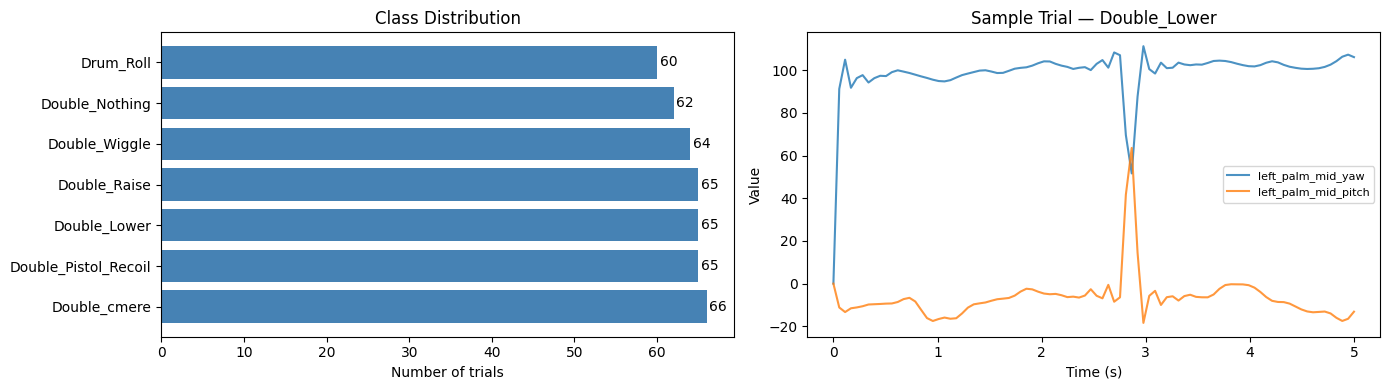

In [12]:
# ── Quick data visualisation: class distribution ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class distribution
label_counts = pd.Series(labels_raw).value_counts()
axes[0].barh(label_counts.index, label_counts.values, color='steelblue')
axes[0].set_xlabel('Number of trials')
axes[0].set_title('Class Distribution')
for i, v in enumerate(label_counts.values):
    axes[0].text(v + 0.3, i, str(v), va='center')

# Sample trial: first two channels
sample = trials_filtered[0]
t_axis = np.linspace(0, 5, sample.shape[0])
axes[1].plot(t_axis, sample[:, 0], label=SENSOR_COLS[0], alpha=0.8)
if sample.shape[1] > 1:
    axes[1].plot(t_axis, sample[:, 1], label=SENSOR_COLS[1], alpha=0.8)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Value')
axes[1].set_title(f'Sample Trial — {labels_raw[0]}')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 4. Training & Evaluation

In [13]:
# ── Define classifiers from config ────────────────────────────────────────────

CLASSIFIER_DEFS = {
    'SVM (RBF)':           SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_STATE, probability=True),
    'SVM (Linear)':        SVC(kernel='linear', C=1, random_state=RANDOM_STATE, probability=True),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'KNN':                 KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'LDA':                 LinearDiscriminantAnalysis(),
}

base_estimators = [
    ("svm_rbf", CLASSIFIER_DEFS["SVM (RBF)"]),
    ("rf", CLASSIFIER_DEFS["Random Forest"]),
    ("logreg", CLASSIFIER_DEFS["Logistic Regression"]),
]


ENSEMBLE_DEFS = {
    "Voting Soft (SVM+RF+LogReg)": VotingClassifier(
        estimators=base_estimators,
        voting="soft",          # use predict_proba and average
        n_jobs=-1
    )
}

# Merge into your classifier definitions
CLASSIFIER_DEFS.update(ENSEMBLE_DEFS)


STACKING_DEFS = {
    "Stacking (SVM+RF+LogReg)": StackingClassifier(
        estimators=base_estimators,
        # cv="prefit",  # use the already fitted base estimators
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        passthrough=False,  # or True if you want raw features + preds
        n_jobs=-1
    )
}

CLASSIFIER_DEFS.update(STACKING_DEFS)



active_classifiers = {k: v for k, v in CLASSIFIER_DEFS.items() if ALGORITHMS.get(k, False)}
print(f'Running {len(active_classifiers)} algorithms: {list(active_classifiers.keys())}')

Running 8 algorithms: ['SVM (RBF)', 'SVM (Linear)', 'Random Forest', 'KNN', 'Logistic Regression', 'LDA', 'Voting Soft (SVM+RF+LogReg)', 'Stacking (SVM+RF+LogReg)']


In [14]:
# ── Print model parameters for all active classifiers ─────────────────────────
# Shows every hyperparameter and (after training) learned model properties.

PARAM_DESCRIPTIONS = {
    # SVM
    'C':               'Regularisation — higher = fits training data more tightly, lower = wider margin (less overfit)',
    'kernel':          'Decision boundary shape: rbf=curved (non-linear), linear=flat hyperplane',
    'gamma':           'RBF kernel width — scale=1/(n_features*X.var()), auto=1/n_features. Higher=more complex boundary',
    # Random Forest
    'n_estimators':    'Number of decision trees in the forest — more trees = more stable, slower',
    'max_depth':       'Max tree depth — None=grow until pure leaves (may overfit)',
    'min_samples_split':'Min samples required to split a node — higher=simpler trees',
    'min_samples_leaf': 'Min samples required at a leaf — higher=smoother decision boundary',
    'max_features':    'Features considered per split — sqrt=sqrt(n_features), None=all features',
    # KNN
    'n_neighbors':     'Number of nearest neighbours to vote — lower=more sensitive to noise, higher=smoother boundary',
    'metric':          'Distance measure used to find neighbours',
    'weights':         'uniform=all neighbours equal vote, distance=closer neighbours weighted more',
    # Logistic Regression
    'max_iter':        'Maximum solver iterations — increase if convergence warning appears',
    'C':               'Inverse regularisation strength — higher=less regularisation (fits training harder)',
    'solver':          'Optimisation algorithm used to fit the model',
    'multi_class':     'Strategy for multi-class: auto selects ovr or multinomial',
    # LDA
    'solver':          'svd=no matrix inversion (stable), lsqr/eigen=faster but less stable',
    'shrinkage':       'Regularisation on covariance matrix — None=no shrinkage',
    'n_components':    'Dimensions to reduce to — None=min(n_classes-1, n_features)',
    # Gradient Boosting
    'learning_rate':   'Shrinks each tree contribution — lower=more trees needed but better generalisation',
    'subsample':       'Fraction of samples per tree — <1.0 adds randomness (stochastic boosting)',
}

print('=' * 70)
print('CLASSIFIER PARAMETERS')
print('=' * 70)

for name, clf in active_classifiers.items():
    params = clf.get_params()
    print(f'\n┌─ {name} ─────────────────────────────────────────')
    print(f'│  Type: {type(clf).__name__}')
    print(f'│')
    for param, value in params.items():
        desc = PARAM_DESCRIPTIONS.get(param, '')
        desc_str = f'  # {desc}' if desc else ''
        print(f'│  {param:<22} = {str(value):<15}{desc_str}')
    print(f'└──────────────────────────────────────────────────')

# ── Post-training learned properties (run after Section 4 training cell) ─────
print()
print('=' * 70)
print('POST-TRAINING LEARNED PROPERTIES  (run after Section 4)')
print('=' * 70)

if 'results' not in dir():
    print('  Classifiers not yet trained — run Section 4 first.')
else:
    for name, res in results.items():
        clf = res['clf']
        print(f'\n  {name}:')

        if hasattr(clf, 'support_vectors_'):
            n_sv = clf.support_vectors_.shape[0]
            pct  = 100 * n_sv / len(X_train)
            print(f'    Support vectors : {n_sv} / {len(X_train)} training samples ({pct:.1f}%)')
            print(f'    (Low % = confident, wide margin. High % = decision boundary uncertain)')

        if hasattr(clf, 'n_iter_'):
            print(f'    Iterations      : {clf.n_iter_}')

        if hasattr(clf, 'feature_importances_'):
            fi   = clf.feature_importances_
            top3 = fi.argsort()[::-1][:3]
            print(f'    Feature importances (top 3 feature indices): {top3}')
            print(f'    Top 3 importance values: {fi[top3].round(4)}')

        if hasattr(clf, 'coef_'):
            coef = clf.coef_
            print(f'    Coefficient matrix shape: {coef.shape}  ({coef.shape[0]} classes × {coef.shape[1]} features)')
            print(f'    Coef magnitude  : mean={abs(coef).mean():.4f}, max={abs(coef).max():.4f}')

        if hasattr(clf, 'scalings_'):
            print(f'    LDA scalings shape: {clf.scalings_.shape}  ({clf.scalings_.shape[1]} discriminant axes)')
            print(f'    Explained variance ratio: {clf.explained_variance_ratio_.round(4) if hasattr(clf, "explained_variance_ratio_") else "N/A"}')
        if hasattr(clf, 'estimators_') and name == 'Random Forest':
            depths = [e.get_depth() for e in clf.estimators_]
            print(f'    Trees grown     : {len(clf.estimators_)}')
            print(f'    Tree depth      : mean={sum(depths)/len(depths):.1f}, max={max(depths)}, min={min(depths)}')


CLASSIFIER PARAMETERS

┌─ SVM (RBF) ─────────────────────────────────────────
│  Type: SVC
│
│  C                      = 10               # Inverse regularisation strength — higher=less regularisation (fits training harder)
│  break_ties             = False          
│  cache_size             = 200            
│  class_weight           = None           
│  coef0                  = 0.0            
│  decision_function_shape = ovr            
│  degree                 = 3              
│  gamma                  = scale            # RBF kernel width — scale=1/(n_features*X.var()), auto=1/n_features. Higher=more complex boundary
│  kernel                 = rbf              # Decision boundary shape: rbf=curved (non-linear), linear=flat hyperplane
│  max_iter               = -1               # Maximum solver iterations — increase if convergence warning appears
│  probability            = True           
│  random_state           = 42             
│  shrinking              = True           


In [15]:
# ── Train and cross-validate each classifier (true LOUO over all users) ──────

# Every user is held out in exactly one fold. The per-fold scores ARE the
# unseen-user generalisation estimate; there is no separate held-out test user.
# We also compute per-user accuracy by collecting fold predictions.

from sklearn.model_selection import cross_val_predict

logo = LeaveOneGroupOut()
n_folds = len(np.unique(groups_train))
print(f"True LOUO CV: {n_folds} folds (one per user)")

results = {}

for name, clf in active_classifiers.items():
    print(f'\n--- {name} ---')

    # Per-fold accuracy (one score per held-out user)
    cv_scores = cross_val_score(
        clf, X_train, y_train,
        groups=groups_train, cv=logo,
        scoring='accuracy', n_jobs=-1,
    )
    print(f'  LOUO CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

    # Per-sample predictions across folds (each sample's prediction comes from
    # the fold in which its user was held out). Used for per-user accuracy and
    # the overall confusion matrix.
    y_pred_cv = cross_val_predict(
        clf, X_train, y_train,
        groups=groups_train, cv=logo, n_jobs=-1,
    )

    # Per-user accuracy table
    per_user = {}
    for u in np.unique(groups_train):
        msk = (groups_train == u)
        per_user[u] = {
            'n_trials': int(msk.sum()),
            'accuracy': float(accuracy_score(y_train[msk], y_pred_cv[msk])),
        }
    # Print compact summary
    for u in sorted(per_user, key=lambda x: int(str(x).split('_')[0]) if str(x).split('_')[0].isdigit() else 9999):
        d = per_user[u]
        print(f'    {u:<14} n={d["n_trials"]:<3}  acc={d["accuracy"]:.4f}')

    # Final model trained on ALL data (for downstream use, e.g. saving).
    clf.fit(X_train, y_train)

    results[name] = {
        'cv_mean':       float(cv_scores.mean()),
        'cv_std':        float(cv_scores.std()),
        'cv_per_fold':   cv_scores.tolist(),
        'cv_user_order': [str(u) for u in np.unique(groups_train)],
        'per_user':      per_user,
        'y_pred_cv':     y_pred_cv,
        'clf':           clf,
    }

print('\n\u2713 All classifiers trained (true LOUO over all users).')

True LOUO CV: 13 folds (one per user)

--- SVM (RBF) ---
  LOUO CV accuracy: 0.8840 ± 0.0828
    1_Alan         n=105  acc=0.8286
    2_Alex         n=105  acc=0.9714
    3_Anghad       n=108  acc=0.9167
    4_Daniel       n=105  acc=0.9143
    6_Harry        n=105  acc=0.9429
    8_Jestin       n=72   acc=0.8750
    11_Mansh       n=105  acc=0.8190
    12_Marcus      n=105  acc=0.6571
    14_StephenV2   n=108  acc=0.9722
    15_Tash        n=105  acc=0.9048
    16_Bella       n=108  acc=0.8611
    17_Raquel      n=105  acc=0.8571
    18_Bridgette   n=105  acc=0.9714

--- SVM (Linear) ---
  LOUO CV accuracy: 0.8809 ± 0.0961
    1_Alan         n=105  acc=0.7714
    2_Alex         n=105  acc=0.9714
    3_Anghad       n=108  acc=0.9167
    4_Daniel       n=105  acc=0.9143
    6_Harry        n=105  acc=0.9429
    8_Jestin       n=72   acc=0.9583
    11_Mansh       n=105  acc=0.8000
    12_Marcus      n=105  acc=0.6286
    14_StephenV2   n=108  acc=0.9722
    15_Tash        n=105  acc=0.885

In [16]:
# ── Per-class classification reports (across all LOUO folds) ─────────────

for name, res in results.items():
    print(f'\n=== {name} (LOUO CV) ===')
    print(classification_report(
        y_train, res['y_pred_cv'],
        target_names=le.classes_,
        zero_division=0
    ))



=== SVM (RBF) (LOUO CV) ===
                      precision    recall  f1-score   support

        Double_Lower       0.89      0.89      0.89       195
      Double_Nothing       0.69      0.66      0.67       186
Double_Pistol_Recoil       0.95      0.89      0.92       195
        Double_Raise       0.92      0.98      0.95       195
       Double_Wiggle       0.90      1.00      0.95       192
        Double_cmere       0.98      0.97      0.98       198
           Drum_Roll       0.82      0.78      0.80       180

            accuracy                           0.88      1341
           macro avg       0.88      0.88      0.88      1341
        weighted avg       0.88      0.88      0.88      1341


=== SVM (Linear) (LOUO CV) ===
                      precision    recall  f1-score   support

        Double_Lower       0.88      0.89      0.89       195
      Double_Nothing       0.77      0.61      0.68       186
Double_Pistol_Recoil       0.90      0.88      0.89       195
     

---
## 5. Data Diagnostics

Quantifies **within-class consistency** and **between-class separation** of the loaded dataset.
Run this after preprocessing to understand how separable your gestures are before training.

- **Within-class cosine similarity** — how alike trials of the same gesture are (1.0 = identical)
- **Separation ratio** — between-class distance ÷ within-class spread. Higher = easier to classify.
- **t-SNE plot** — 2D projection of the feature space to visually confirm class clustering.

WITHIN-CLASS TRIAL SIMILARITY  (cosine, 1.0 = identical)
  Double_Lower               mean=0.8089  min=0.5289  feat_std=0.08
  Double_Nothing             mean=0.6791  min=0.3397  feat_std=0.13
  Double_Pistol_Recoil       mean=0.7719  min=0.3923  feat_std=0.10
  Double_Raise               mean=0.8263  min=0.6780  feat_std=0.10
  Double_Wiggle              mean=0.8141  min=0.6279  feat_std=0.07
  Double_cmere               mean=0.7876  min=0.6343  feat_std=0.11
  Drum_Roll                  mean=0.7826  min=0.5057  feat_std=0.09

  Interpretation:
    > 0.95  → very consistent (model generalises easily within-session)
    < 0.80  → high variance (harder to learn, more robust to new sessions)

BETWEEN-CLASS SEPARATION  (ratio = between-dist / within-spread)
  Double_Lower         vs Double_Nothing        ratio=   82.3x  [easy]
  Double_Lower         vs Double_Pistol_Recoil  ratio=  119.3x  [trivial]
  Double_Lower         vs Double_Raise          ratio=  196.9x  [trivial]
  Double_Lower  

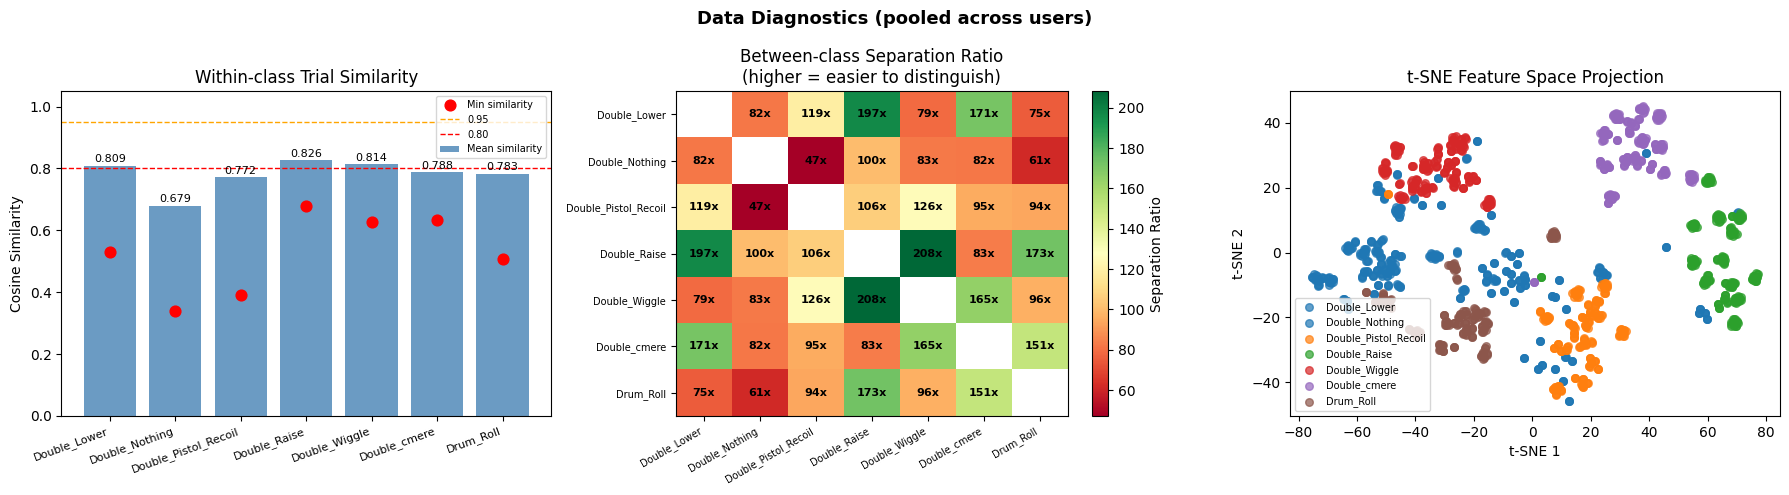

In [17]:
# ── Section 5: Data Diagnostics ───────────────────────────────────────────────
# Runs on the feature matrix X and labels produced in Section 3.
# Must be run after the preprocessing cells.

from sklearn.manifold import TSNE
from itertools import combinations

# Initialise (once) the diagnostic-figures registry used by the PDF report.
import os
try:
    diagnostic_figures
except NameError:
    diagnostic_figures = []   # list of (title, png_path) tuples
DIAG_FIG_DIR = os.path.join(str(REPORT_OUTPUT_DIR), '_diag_figs')
os.makedirs(DIAG_FIG_DIR, exist_ok=True)


short_names = [lbl.replace('TwoHandDynamic_','Dyn_').replace('TwoHand_','')
               .replace('_filtered_butterworth_lp','') for lbl in le.classes_]
short_map   = dict(zip(le.classes_, short_names))

# ── 1. Within-class cosine similarity ────────────────────────────────────────
print('=' * 65)
print('WITHIN-CLASS TRIAL SIMILARITY  (cosine, 1.0 = identical)')
print('=' * 65)

within_stats = {}
for cls_id, cls_name in enumerate(le.classes_):
    mask    = (y == cls_id)
    feats   = X[mask]
    norms   = np.linalg.norm(feats, axis=1, keepdims=True)
    feats_n = feats / (norms + 1e-8)
    sim     = feats_n @ feats_n.T
    np.fill_diagonal(sim, np.nan)
    mean_sim = float(np.nanmean(sim))
    min_sim  = float(np.nanmin(sim))
    feat_std = float(feats.std(axis=0).mean())
    within_stats[cls_name] = {'mean_sim': mean_sim, 'min_sim': min_sim, 'feat_std': feat_std}
    print(f'  {short_map[cls_name]:<25}  mean={mean_sim:.4f}  min={min_sim:.4f}  feat_std={feat_std:.2f}')

print()
print('  Interpretation:')
print('    > 0.95  → very consistent (model generalises easily within-session)')
print('    < 0.80  → high variance (harder to learn, more robust to new sessions)')

# ── 2. Between-class separation ratios ───────────────────────────────────────
print()
print('=' * 65)
print('BETWEEN-CLASS SEPARATION  (ratio = between-dist / within-spread)')
print('=' * 65)

class_means  = {cls_name: X[y == cls_id].mean(axis=0)
                for cls_id, cls_name in enumerate(le.classes_)}
pairs        = list(combinations(le.classes_, 2))
ratio_matrix = np.zeros((len(le.classes_), len(le.classes_)))

for cls_a, cls_b in pairs:
    dist   = np.linalg.norm(class_means[cls_a] - class_means[cls_b])
    std_a  = within_stats[cls_a]['feat_std']
    std_b  = within_stats[cls_b]['feat_std']
    ratio  = dist / ((std_a + std_b) / 2)
    idx_a  = list(le.classes_).index(cls_a)
    idx_b  = list(le.classes_).index(cls_b)
    ratio_matrix[idx_a, idx_b] = ratio
    ratio_matrix[idx_b, idx_a] = ratio
    difficulty = ('trivial' if ratio > 100 else
                  'easy'    if ratio > 20  else
                  'moderate'if ratio > 5   else 'hard')
    print(f'  {short_map[cls_a]:<20} vs {short_map[cls_b]:<20}  ratio={ratio:>7.1f}x  [{difficulty}]')

print()
print('  Interpretation:')
print('    > 100x  → trivially separable')
print('    20-100x → easy')
print('    5-20x   → moderate')
print('    < 5x    → hard (expect confusion)')

# ── 3. Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Within-class similarity
ax = axes[0]
names_short = [short_map[c] for c in le.classes_]
means_sim   = [within_stats[c]['mean_sim'] for c in le.classes_]
mins_sim    = [within_stats[c]['min_sim']  for c in le.classes_]
x_pos = np.arange(len(le.classes_))
bars  = ax.bar(x_pos, means_sim, color='steelblue', alpha=0.8, label='Mean similarity')
ax.scatter(x_pos, mins_sim, color='red', zorder=5, label='Min similarity', s=60)
ax.axhline(0.95, color='orange', linestyle='--', linewidth=1, label='0.95')
ax.axhline(0.80, color='red',    linestyle='--', linewidth=1, label='0.80')
ax.set_xticks(x_pos)
ax.set_xticklabels(names_short, rotation=20, ha='right', fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Cosine Similarity')
ax.set_title('Within-class Trial Similarity')
ax.legend(fontsize=7)
for bar, val in zip(bars, means_sim):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# Plot 2: Separation ratio heatmap
ax = axes[1]
mask_diag     = np.eye(len(le.classes_), dtype=bool)
ratio_display = ratio_matrix.copy().astype(float)
ratio_display[mask_diag] = np.nan
im = ax.imshow(ratio_display, cmap='RdYlGn', aspect='auto')
plt.colorbar(im, ax=ax, label='Separation Ratio')
ax.set_xticks(range(len(le.classes_)))
ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(names_short, rotation=30, ha='right', fontsize=7)
ax.set_yticklabels(names_short, fontsize=7)
ax.set_title('Between-class Separation Ratio\n(higher = easier to distinguish)')
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        if not mask_diag[i, j]:
            _v = ratio_matrix[i, j]
            _lbl = (f'{_v:.0f}x' if _v >= 10
                    else f'{_v:.1f}x' if _v >= 1
                    else f'{_v:.2f}')
            ax.text(j, i, _lbl,
                    ha='center', va='center', fontsize=8, fontweight='bold')

# Plot 3: t-SNE (PCA->50 first; t-SNE on high-dim is wasteful)
# Fix: avoid sklearn's init='pca' branch — it rescales the init to std=1e-4,
# which collapses to a near-1D embedding when combined with learning_rate='auto'
# (= max(N/12/4, 50) ≈ 50) and only 500 iterations. We build a properly-scaled
# PCA init ourselves and use an explicit learning rate + more iterations.
from sklearn.decomposition import PCA as _PCA_for_tsne
ax   = axes[2]
# Perplexity: must be < N. Use a sensible heuristic and clamp to [5, 30].
_N_pool = len(X)
perp = max(5, min(30, (_N_pool - 1) // 3))
_n_pca = min(50, X.shape[1], X.shape[0] - 1)
_X_low = _PCA_for_tsne(n_components=_n_pca, random_state=RANDOM_STATE).fit_transform(X)
# Build our own 2-D PCA init and standardise it (mean 0, std 1) instead of
# sklearn's 1e-4 scaling. Multiplied by ~10 to give the gradient room to move.
_init2d = _PCA_for_tsne(n_components=2, random_state=RANDOM_STATE).fit_transform(_X_low)
_init2d = (_init2d - _init2d.mean(0)) / (_init2d.std(0) + 1e-12)
_init2d = (_init2d * 10.0).astype(np.float32)
_lr_pool = max(200.0, _N_pool / 12.0)   # explicit, never tiny
tsne = TSNE(n_components=2, perplexity=perp, random_state=RANDOM_STATE,
            max_iter=1500, init=_init2d, learning_rate=_lr_pool,
            early_exaggeration=12.0)
X_2d = tsne.fit_transform(_X_low)
colours = plt.cm.tab10(np.linspace(0, 0.5, len(le.classes_)))
for cls_id, (cls_name, col) in enumerate(zip(le.classes_, colours)):
    mask = (y == cls_id)
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               label=short_map[cls_name], alpha=0.7, s=30, color=col)
ax.set_title('t-SNE Feature Space Projection')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(fontsize=7, loc='best')

plt.suptitle('Data Diagnostics (pooled across users)', fontsize=13, fontweight='bold')
plt.tight_layout()
_pooled_path = os.path.join(DIAG_FIG_DIR, 'diag_pooled.png')
plt.savefig(_pooled_path, dpi=110, bbox_inches='tight')
diagnostic_figures.append(('Pooled diagnostics — extracted features (across all users)', _pooled_path))
plt.show()


Per-user diagnostics (13 users, 7 classes):

(B) EXTRACTED FEATURES — feature_mode=stats+fft, normalisation=minmax

--- 11_Mansh  (35 trials) ---


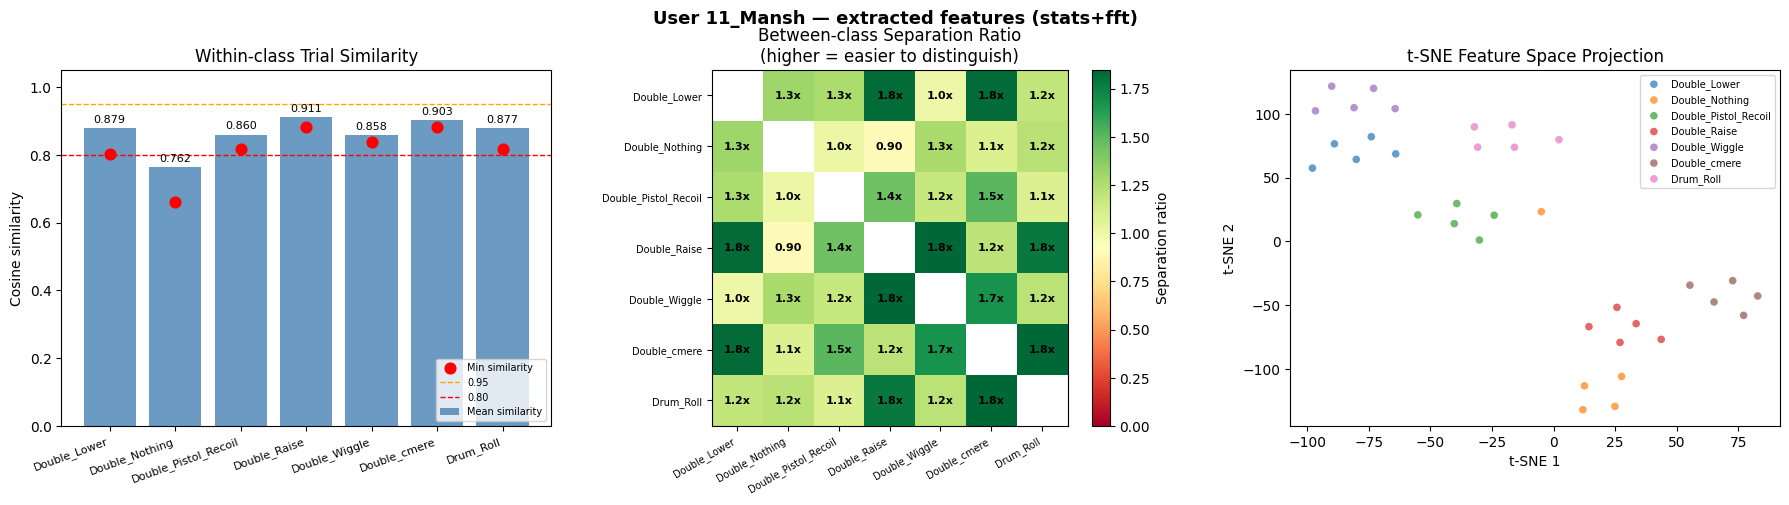


--- 12_Marcus  (35 trials) ---


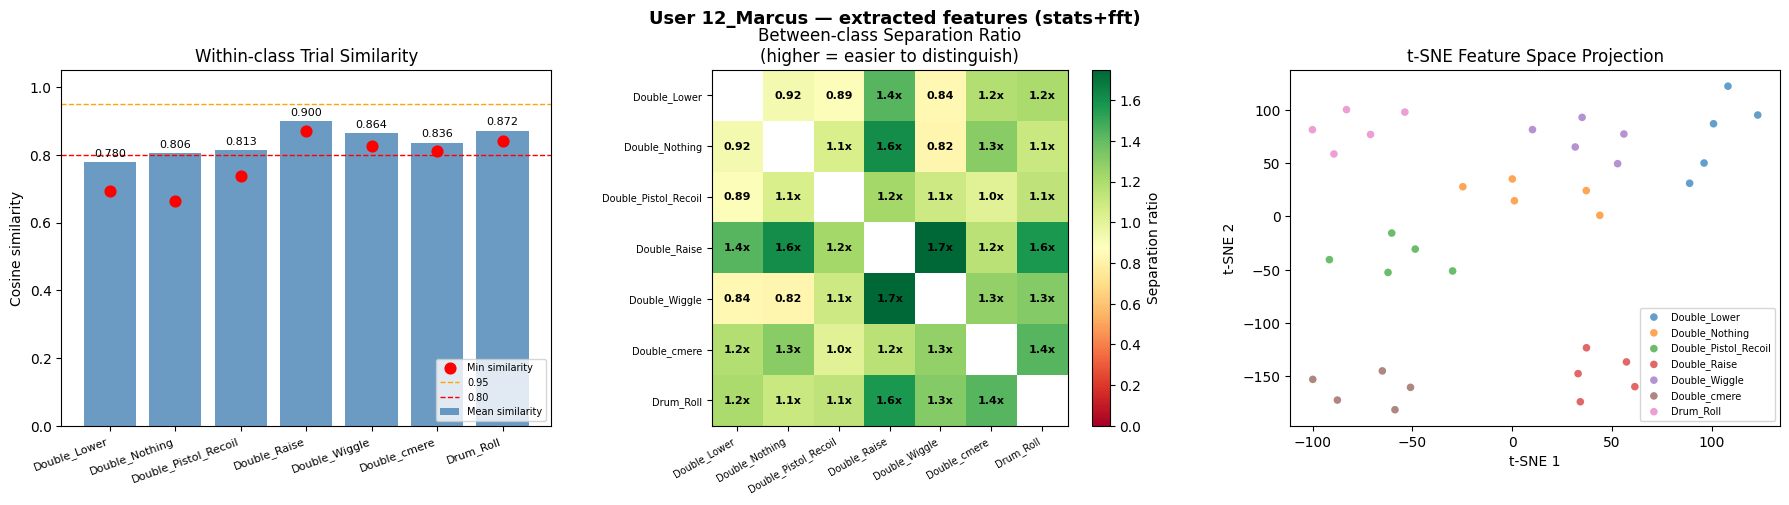


--- 14_StephenV2  (36 trials) ---


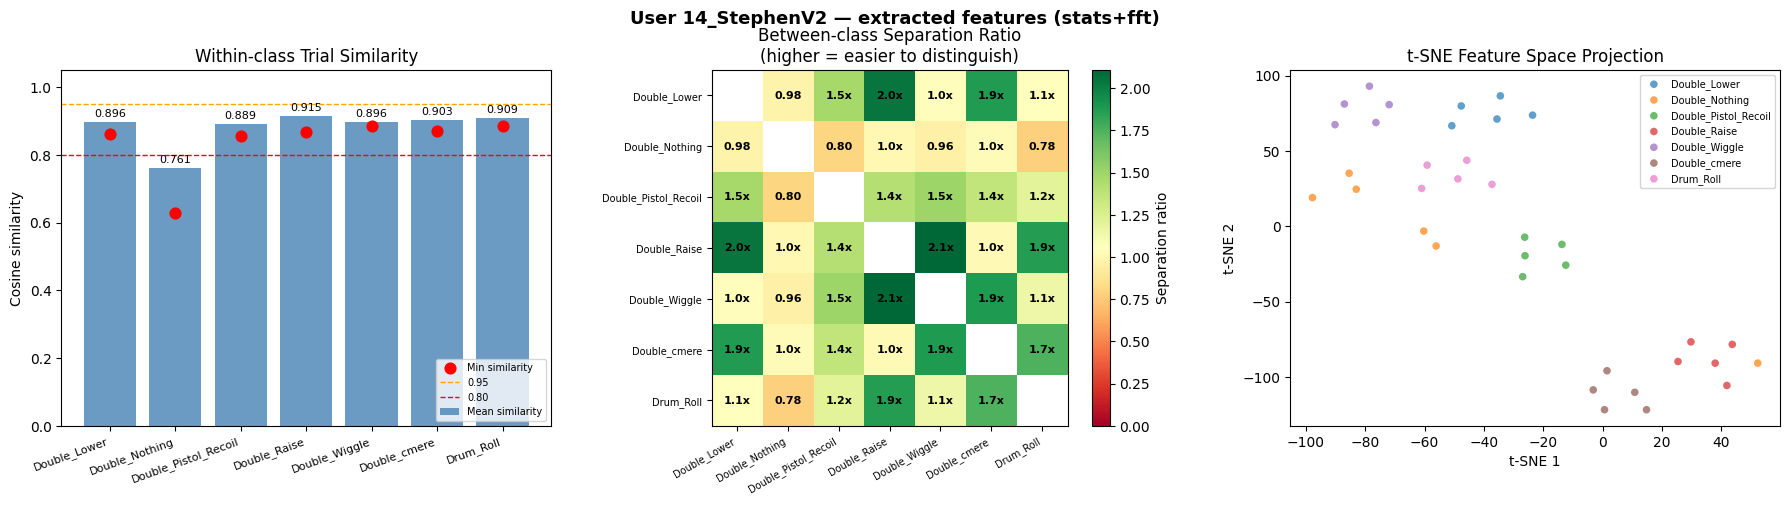


--- 15_Tash  (35 trials) ---


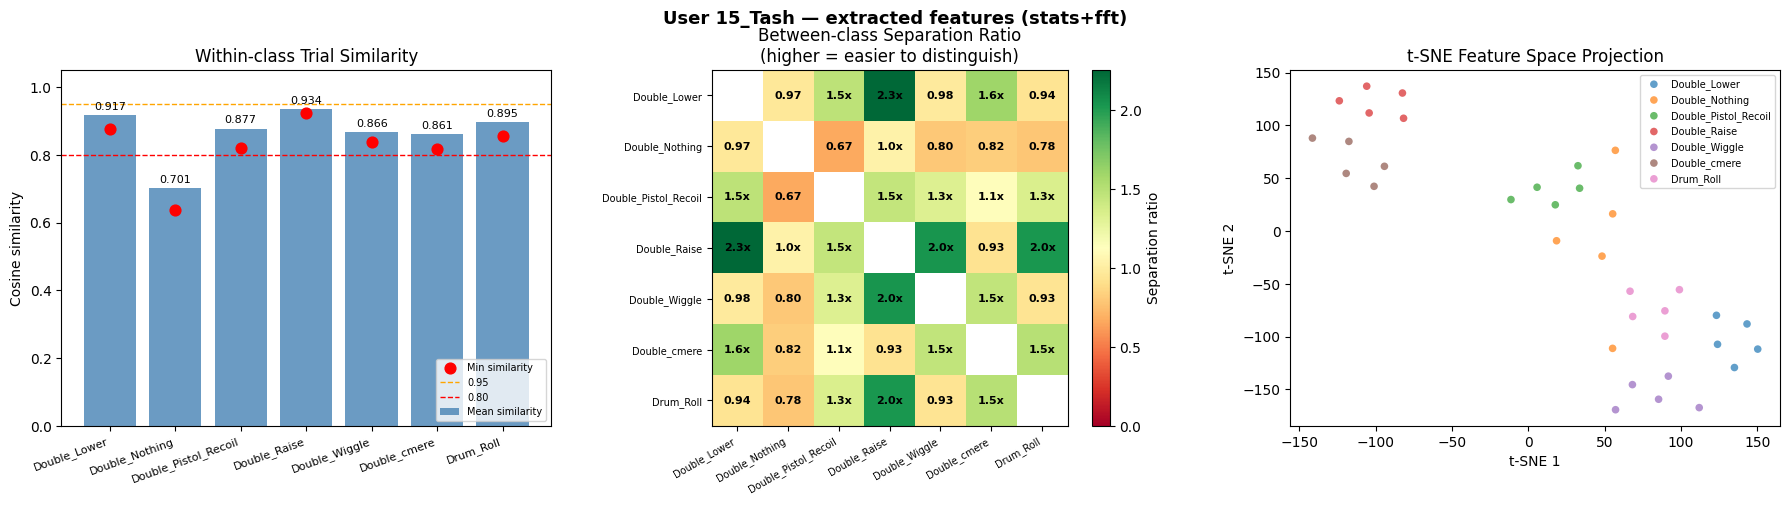


--- 16_Bella  (36 trials) ---


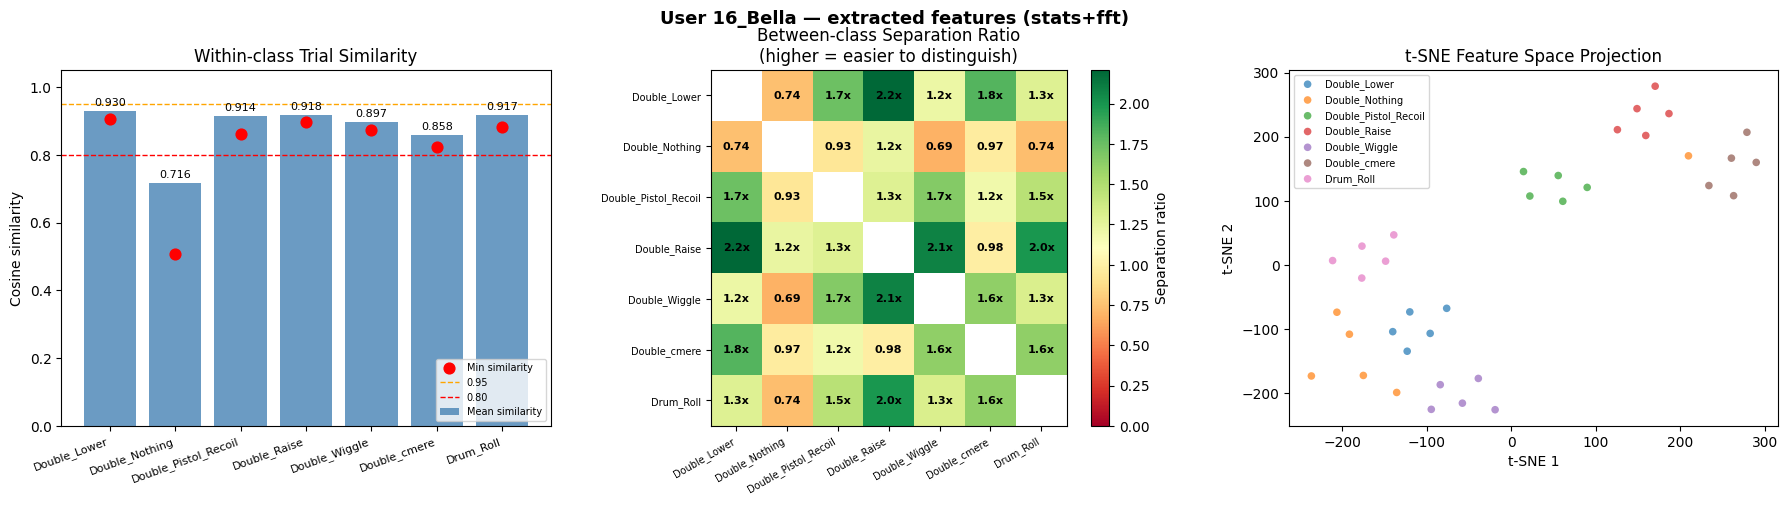


--- 17_Raquel  (35 trials) ---


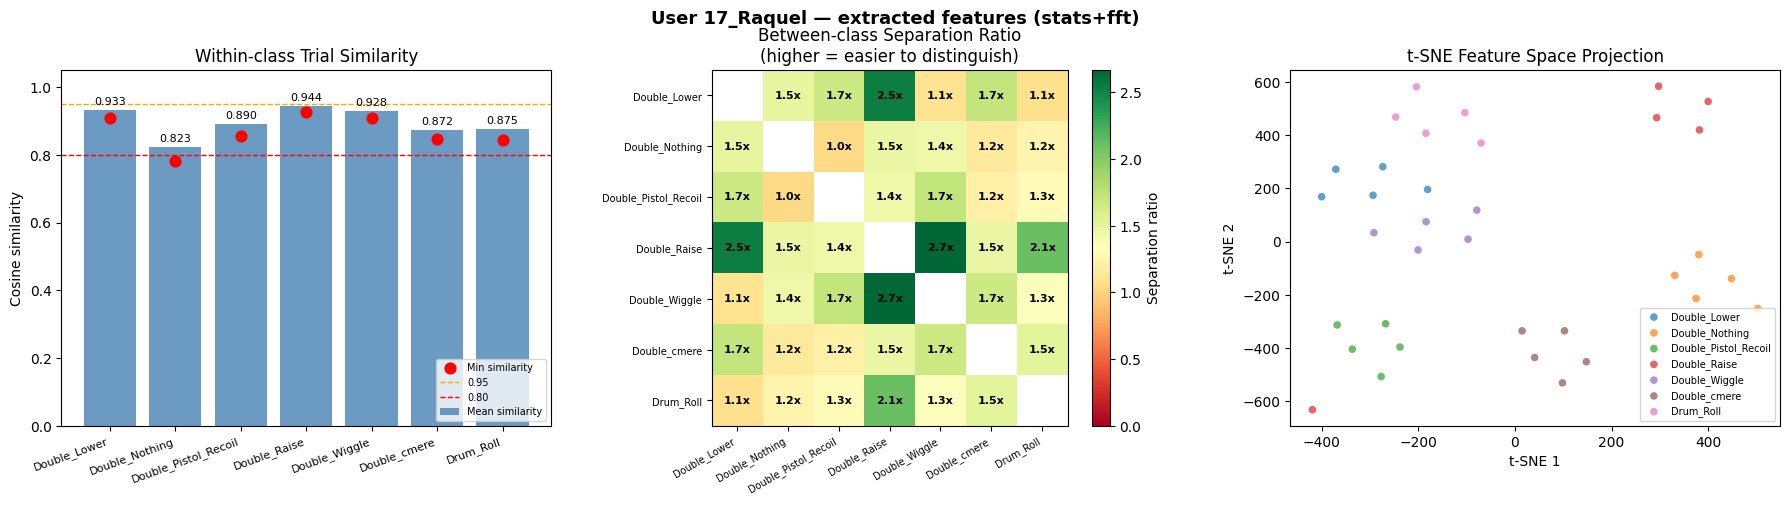


--- 18_Bridgette  (35 trials) ---


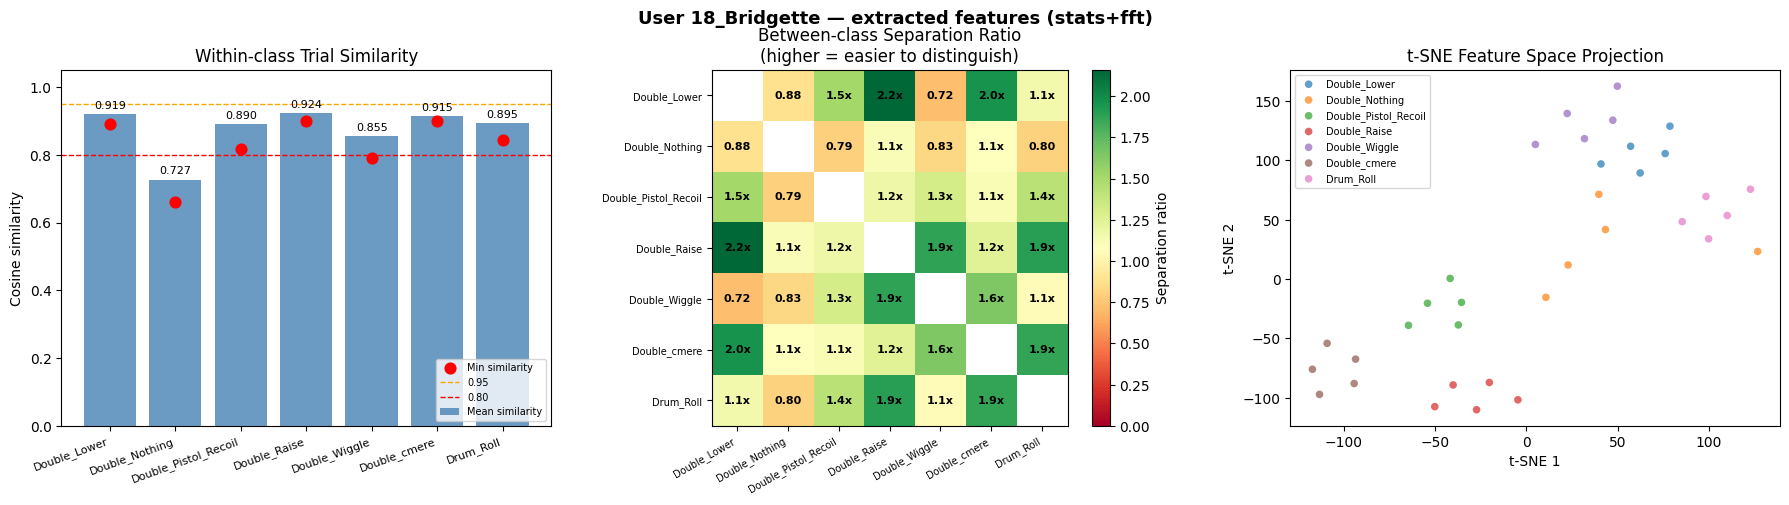


--- 1_Alan  (35 trials) ---


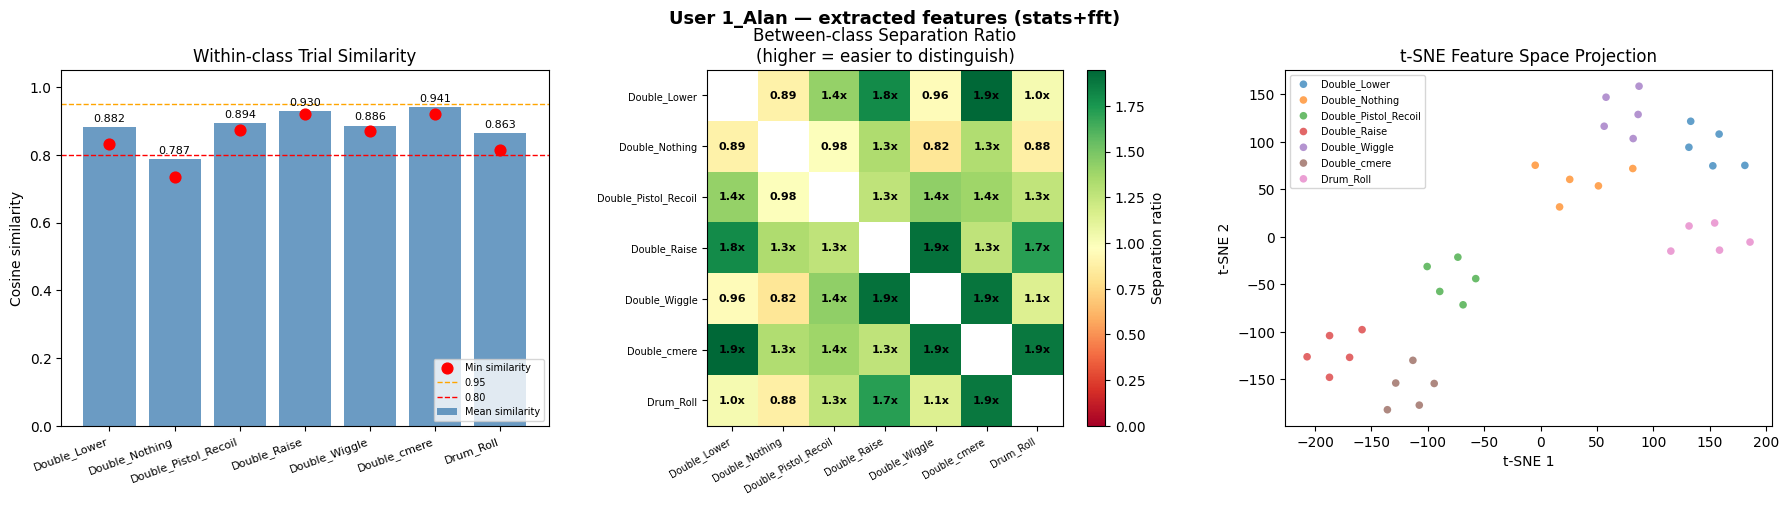


--- 2_Alex  (35 trials) ---


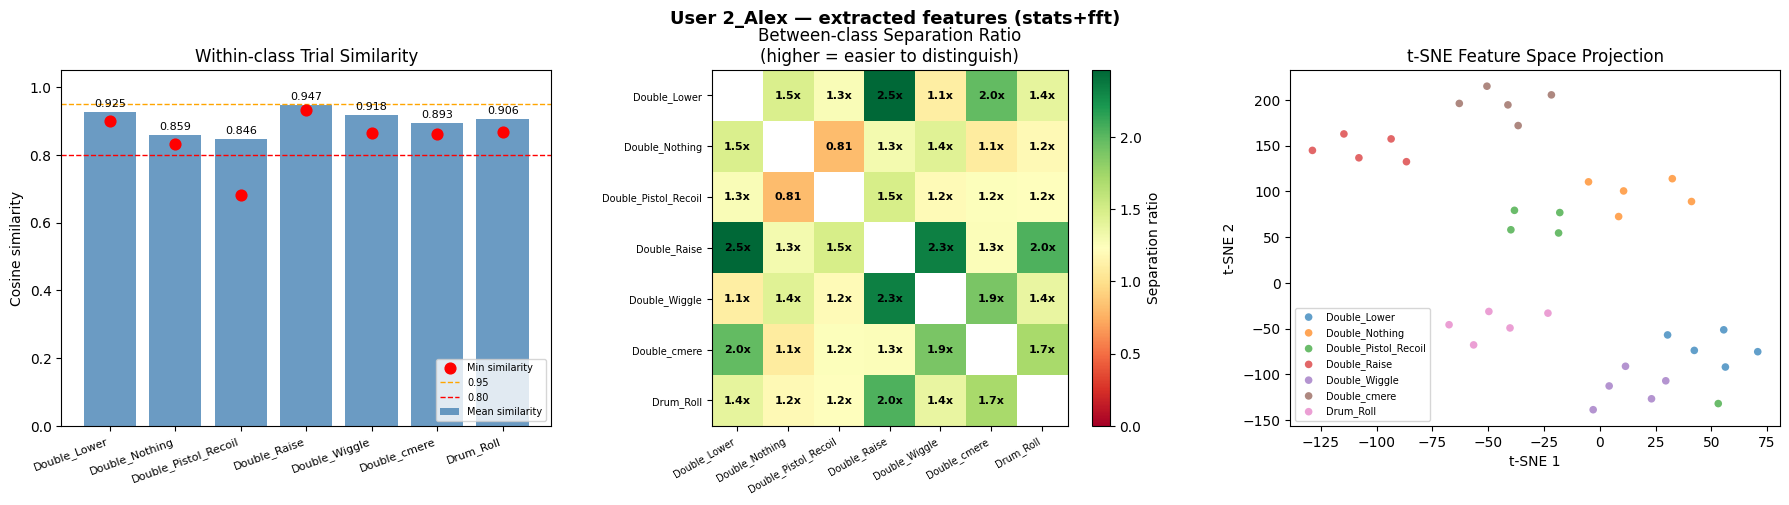


--- 3_Anghad  (36 trials) ---


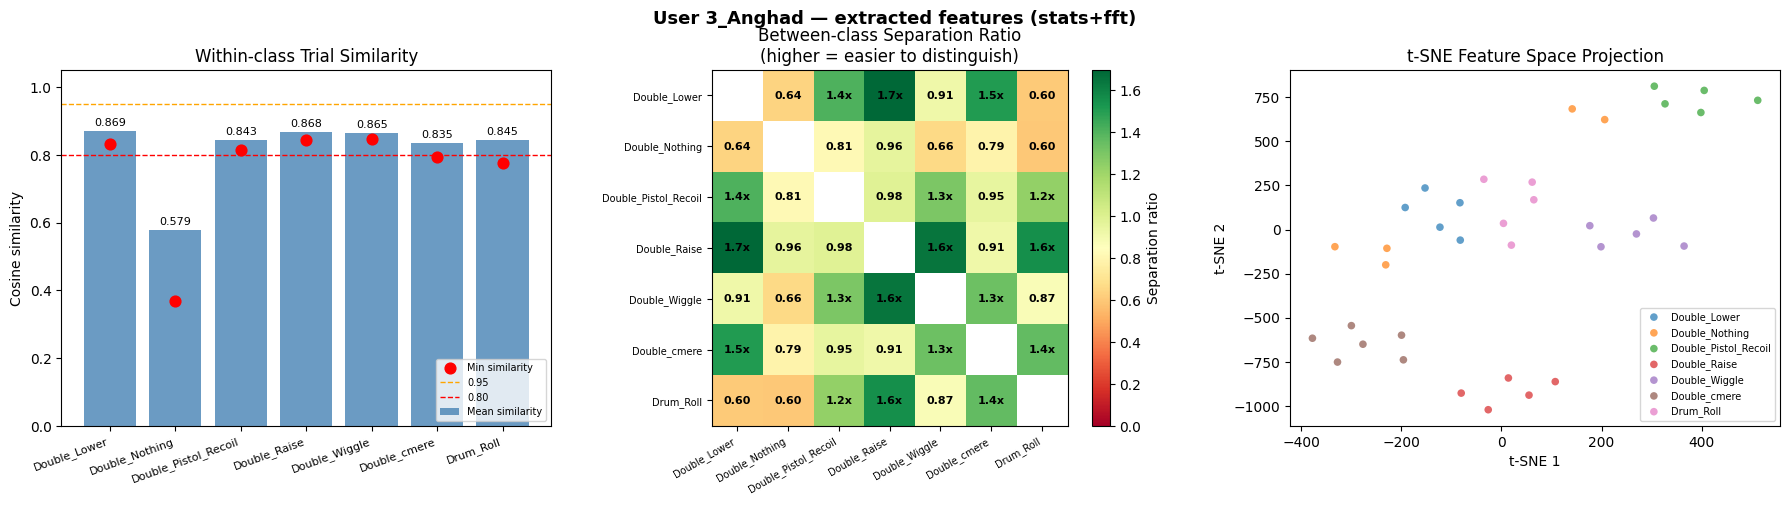


--- 4_Daniel  (35 trials) ---


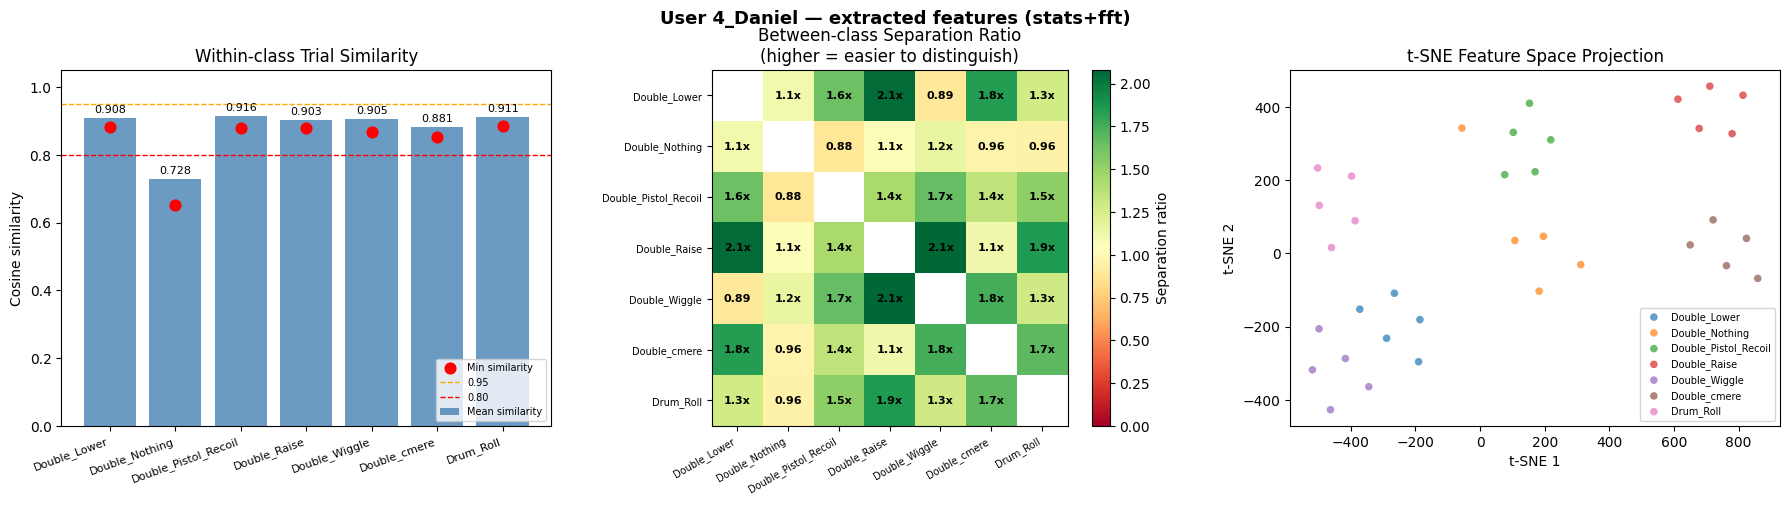


--- 6_Harry  (35 trials) ---


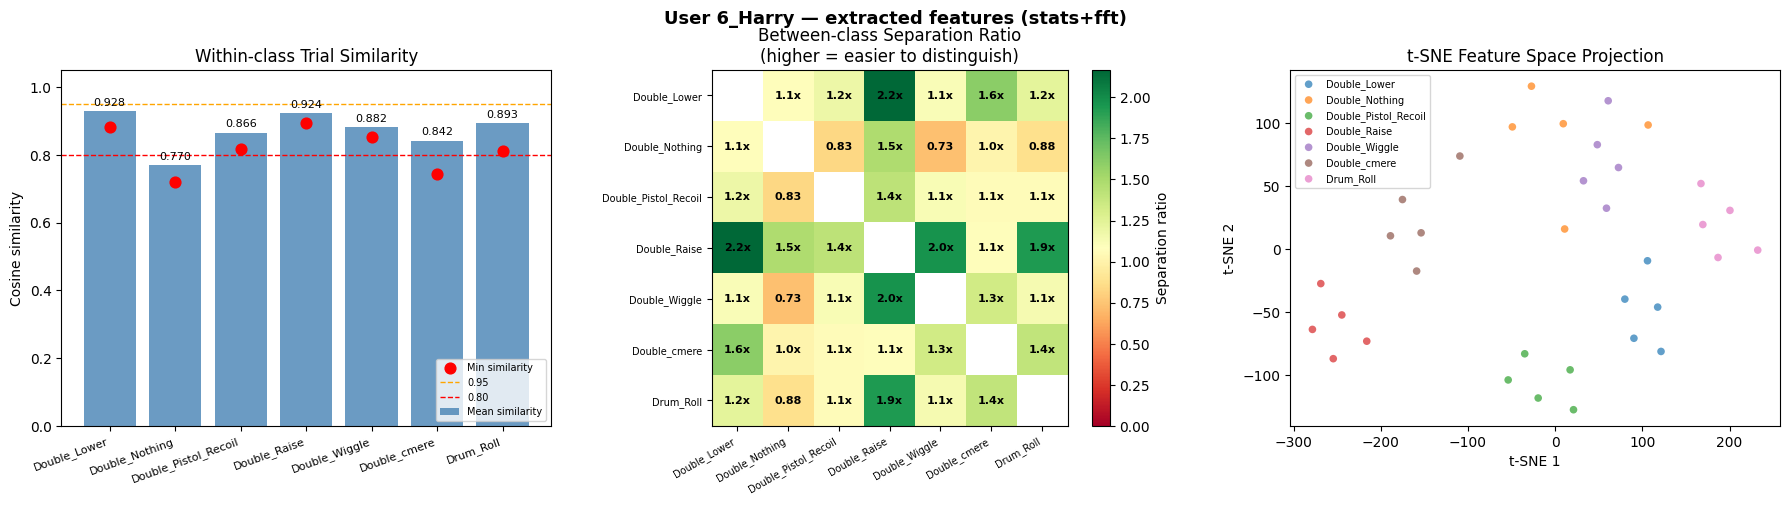


--- 8_Jestin  (24 trials) ---


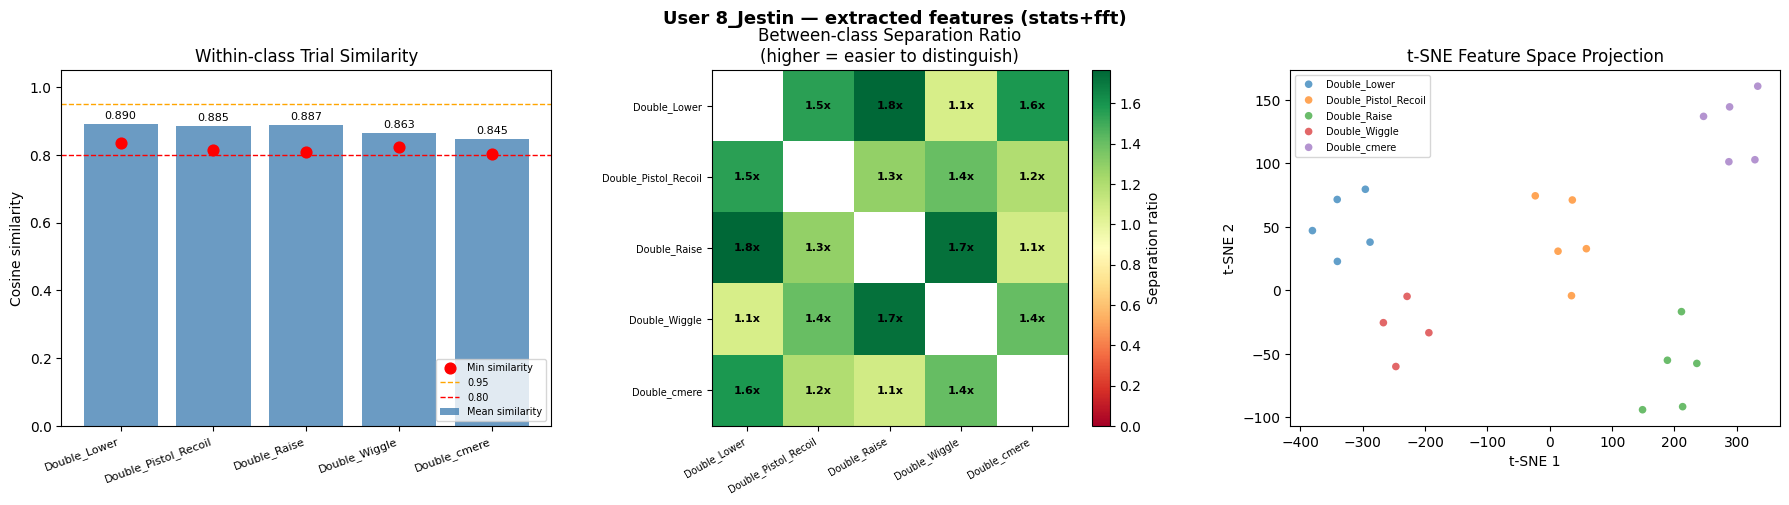


Done — per-user diagnostics rendered.


In [18]:
# ── Section 5b: Per-user Data Diagnostics ────────────────────────────────────
# One 3-panel figure per detected user, computed twice:
#   (A) on RAW filtered trials (each trial flattened to T*C)
#       → similarities/separations in natural sensor units
#   (B) on the EXTRACTED feature matrix X (stats/fft/flatten — whatever
#       FEATURE_MODE is set to) → shows how feature extraction warps the
#       per-user picture vs the raw signal.
# Skips users with fewer than 2 trials in any class for that data source.

from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import pdist


def _fmt_ratio(v):
    if np.isnan(v):       return ''
    if v >= 10:           return f'{v:.0f}x'
    if v >= 1:            return f'{v:.1f}x'
    return f'{v:.2f}'


def _render_diag_figure(X_feat, y_str, classes, title_suffix):
    """Render one 3-panel figure (within-class bars, separation heatmap, t-SNE)
    on a (N, D) feature matrix X_feat with string labels y_str.
    classes is the sorted unique list to use as axis order.
    Returns True if the figure was rendered, False otherwise.
    """
    if len(X_feat) < 2:
        print(f'  {title_suffix}: skipped (only {len(X_feat)} trials)')
        return False
    classes = [c for c in classes if (y_str == c).sum() >= 1]
    if len(classes) < 2:
        print(f'  {title_suffix}: skipped (<2 classes)')
        return False

    # ── Within-class cosine similarity ────────────────────────────────────
    wc_mean, wc_min = [], []
    for c in classes:
        sub = X_feat[y_str == c]
        if len(sub) < 2:
            wc_mean.append(np.nan); wc_min.append(np.nan); continue
        sim = cosine_similarity(sub)
        iu  = np.triu_indices_from(sim, k=1)
        wc_mean.append(float(np.mean(sim[iu])))
        wc_min.append (float(np.min (sim[iu])))

    # ── Between-class separation: centroid-distance / mean within-spread ─
    centroids = np.array([X_feat[y_str == c].mean(axis=0) for c in classes])
    within_spread = []
    for c in classes:
        sub = X_feat[y_str == c]
        within_spread.append(float(np.mean(pdist(sub))) if len(sub) >= 2 else np.nan)
    within_spread = np.array(within_spread)
    C = len(classes)
    ratio_mat = np.full((C, C), np.nan)
    for i in range(C):
        for j in range(C):
            if i == j: continue
            bd = float(np.linalg.norm(centroids[i] - centroids[j]))
            ws = 0.5 * (within_spread[i] + within_spread[j])
            if np.isfinite(ws) and ws > 0:
                ratio_mat[i, j] = bd / ws

    # ── Figure ───────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. within-class bars
    ax = axes[0]
    xp = np.arange(C)
    ax.bar(xp, wc_mean, color='steelblue', alpha=0.8, label='Mean similarity')
    ax.scatter(xp, wc_min, color='red', zorder=5, s=60, label='Min similarity')
    ax.axhline(0.95, color='orange', linestyle='--', lw=1, label='0.95')
    ax.axhline(0.80, color='red',    linestyle='--', lw=1, label='0.80')
    for i, m in enumerate(wc_mean):
        if not np.isnan(m):
            ax.text(i, m + 0.01, f'{m:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_ylim(0.0, 1.05); ax.set_xticks(xp)
    ax.set_xticklabels(classes, rotation=20, ha='right', fontsize=8)
    ax.set_ylabel('Cosine similarity')
    ax.set_title('Within-class Trial Similarity')
    ax.legend(fontsize=7, loc='lower right')

    # 2. separation heatmap
    ax = axes[1]
    vmax = float(np.nanmax(ratio_mat)) if np.isfinite(np.nanmax(ratio_mat)) else 1.0
    im = ax.imshow(ratio_mat, cmap='RdYlGn', vmin=0.0, vmax=vmax)
    plt.colorbar(im, ax=ax, label='Separation ratio')
    ax.set_xticks(range(C)); ax.set_yticks(range(C))
    ax.set_xticklabels(classes, rotation=30, ha='right', fontsize=7)
    ax.set_yticklabels(classes, fontsize=7)
    ax.set_title('Between-class Separation Ratio\n(higher = easier to distinguish)')
    for i in range(C):
        for j in range(C):
            v = ratio_mat[i, j]
            if not np.isnan(v):
                ax.text(j, i, _fmt_ratio(v),
                        ha='center', va='center', fontsize=8, fontweight='bold',
                        color='black')

    # 3. t-SNE
    # Fix: sklearn's init='pca' scales the init to std=1e-4, which combined with
    # learning_rate='auto' (≈50 for small per-user N) leaves the embedding stuck
    # at its initial 1e-4 scale → appears as a tight line/blob. We construct the
    # PCA init ourselves at unit scale and use an explicit learning rate +
    # more iterations.
    ax = axes[2]
    if len(X_feat) >= 4:
        try:
            _N_user = len(X_feat)
            # Perplexity must be < N. For ~35 trials a perp of ~8-10 works well.
            perp = max(5, min(30, (_N_user - 1) // 3))
            # PCA->50 first so each per-user t-SNE is on a compact matrix.
            from sklearn.decomposition import PCA as _PCA_per_user
            _n_pca = min(50, X_feat.shape[1], X_feat.shape[0] - 1)
            _X_low = _PCA_per_user(n_components=_n_pca,
                                   random_state=RANDOM_STATE).fit_transform(X_feat)
            # Properly-scaled PCA init (std 1 per axis → ×10 for gradient room).
            _init2d = _PCA_per_user(n_components=2,
                                    random_state=RANDOM_STATE).fit_transform(_X_low)
            _init2d = (_init2d - _init2d.mean(0)) / (_init2d.std(0) + 1e-12)
            _init2d = (_init2d * 10.0).astype(np.float32)
            _lr_user = max(200.0, _N_user / 12.0)
            tsne = TSNE(n_components=2, perplexity=perp,
                        random_state=RANDOM_STATE, init=_init2d,
                        learning_rate=_lr_user, max_iter=1500,
                        early_exaggeration=12.0)
            emb = tsne.fit_transform(_X_low)
            palette = plt.cm.tab10(np.linspace(0, 1, max(C, 10)))
            for i, c in enumerate(classes):
                msk = (y_str == c)
                ax.scatter(emb[msk, 0], emb[msk, 1],
                           s=30, alpha=0.7, color=palette[i % len(palette)],
                           label=c, edgecolors='none')
            ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
            ax.set_title('t-SNE Feature Space Projection')
            ax.legend(fontsize=7, loc='best')
        except Exception as e:
            ax.text(0.5, 0.5, f't-SNE failed:\n{e}',
                    transform=ax.transAxes, ha='center', va='center')
            ax.set_axis_off()
    else:
        ax.text(0.5, 0.5, f'(t-SNE skipped — only {len(X_feat)} trials)',
                transform=ax.transAxes, ha='center', va='center')
        ax.set_axis_off()

    plt.suptitle(title_suffix, fontsize=13, fontweight='bold')
    plt.tight_layout()
    # Save figure for the PDF report
    _safe = ''.join(ch if ch.isalnum() else '_' for ch in title_suffix)[:80]
    _png  = os.path.join(DIAG_FIG_DIR, f'diag_{_safe}.png')
    plt.savefig(_png, dpi=110, bbox_inches='tight')
    diagnostic_figures.append((title_suffix, _png))
    plt.show()
    return True


# Per-user t-SNE / similarity / separation on the EXTRACTED feature
# matrix only. Panel A (raw flattened trials) was removed because it was
# the dominant runtime cost (~2000-dim per-user t-SNE) with little extra
# diagnostic value over Panel B.
_raw_y       = np.array(labels_raw)
_users_arr   = np.array(users_raw)
_classes_all = sorted(np.unique(_raw_y).tolist())
_users_sorted = sorted(np.unique(_users_arr).tolist())

print(f'\nPer-user diagnostics ({len(_users_sorted)} users, '
      f'{len(_classes_all)} classes):')

# ── (B) Extracted feature matrix X ───────────────────────────────────────────
# X / y are encoded; we need to align them back to users. They were built from
# trials_train_aug, NOT from trials_filtered. Per-user
# diagnostics on the augmented training pool would mix in synthetic copies,
# which would mask exactly what we want to see.
#
# Cleanest approach: re-extract features on the ORIGINAL (un-augmented,
# un-split) trials_filtered list so each real trial maps 1:1 to a user.
print('\n' + '=' * 65)
print(f'(B) EXTRACTED FEATURES — feature_mode={FEATURE_MODE}, '
      f'normalisation={NORMALISATION}')
print('=' * 65)
X_feat_all = extract_features(trials_filtered, FEATURE_MODE, SAMPLING_RATE_HZ)
X_feat_all = np.nan_to_num(X_feat_all, nan=0.0, posinf=0.0, neginf=0.0)
if NORMALISATION == 'standard':
    _sc = StandardScaler().fit(X_feat_all); X_feat_all = _sc.transform(X_feat_all)
elif NORMALISATION == 'minmax':
    _sc = MinMaxScaler().fit(X_feat_all);   X_feat_all = _sc.transform(X_feat_all)
# (no scaler when NORMALISATION is anything else)

for u in _users_sorted:
    msk = (_users_arr == u)
    print(f'\n--- {u}  ({msk.sum()} trials) ---')
    _render_diag_figure(
        X_feat_all[msk], _raw_y[msk], _classes_all,
        title_suffix=f'User {u} — extracted features ({FEATURE_MODE})',
    )

print('\nDone — per-user diagnostics rendered.')


---
## 6. Results Comparison

In [19]:
# ── Summary table (LOUO CV) ────────────────────────────

summary = pd.DataFrame({
    'Algorithm':     list(results.keys()),
    'CV Acc (mean)': [f"{r['cv_mean']:.4f}" for r in results.values()],
    'CV Acc (±std)': [f"{r['cv_std']:.4f}"  for r in results.values()],
    'CV min':        [f"{min(r['cv_per_fold']):.4f}" for r in results.values()],
    'CV max':        [f"{max(r['cv_per_fold']):.4f}" for r in results.values()],
})
summary = summary.sort_values('CV Acc (mean)', ascending=False).reset_index(drop=True)
print('\n=== Results Summary (LOUO CV across all users) ===')
print(summary.to_string(index=False))



=== Results Summary (LOUO CV across all users) ===
                  Algorithm CV Acc (mean) CV Acc (±std) CV min CV max
              Random Forest        0.8988        0.0805 0.7238 1.0000
Voting Soft (SVM+RF+LogReg)        0.8970        0.0887 0.6571 0.9722
   Stacking (SVM+RF+LogReg)        0.8954        0.0901 0.6667 1.0000
        Logistic Regression        0.8947        0.0863 0.6571 0.9722
                  SVM (RBF)        0.8840        0.0828 0.6571 0.9722
               SVM (Linear)        0.8809        0.0961 0.6286 0.9722
                        KNN        0.8253        0.0508 0.7143 0.9167
                        LDA        0.4775        0.1661 0.2286 0.8000


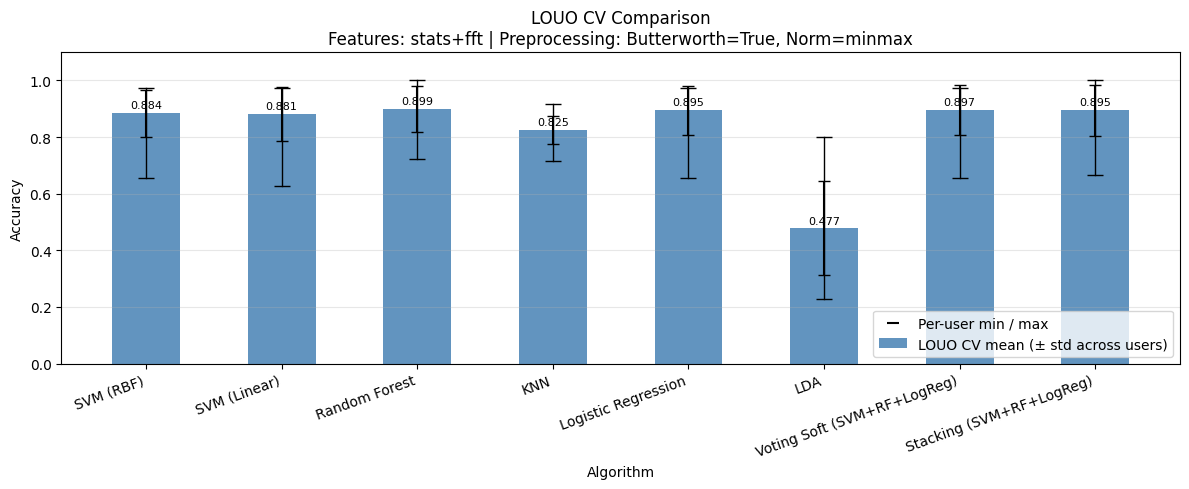

In [20]:
# ── Bar chart: LOUO CV mean with min/max envelope ────────────────────

names    = list(results.keys())
cv_means = [results[n]['cv_mean'] for n in names]
cv_stds  = [results[n]['cv_std']  for n in names]
cv_mins  = [min(results[n]['cv_per_fold']) for n in names]
cv_maxs  = [max(results[n]['cv_per_fold']) for n in names]

x = np.arange(len(names))
width = 0.5

fig, ax = plt.subplots(figsize=(max(8, len(names) * 1.5), 5))
ax.bar(x, cv_means, width, yerr=cv_stds,
       label='LOUO CV mean (± std across users)', color='steelblue',
       capsize=4, alpha=0.85)
# Whisker-style overlay for min/max fold accuracy
for xi, (lo, hi) in enumerate(zip(cv_mins, cv_maxs)):
    ax.plot([xi, xi], [lo, hi], color='black', lw=1.0)
    ax.plot(xi, lo, marker='_', color='black', markersize=12)
    ax.plot(xi, hi, marker='_', color='black', markersize=12)
ax.scatter([], [], color='black', marker='_', label='Per-user min / max', s=80)

ax.set_xlabel('Algorithm')
ax.set_ylabel('Accuracy')
ax.set_title(f'LOUO CV Comparison\n'
             f'Features: {FEATURE_MODE} | '
             f'Preprocessing: Butterworth={APPLY_BUTTERWORTH}, Norm={NORMALISATION}')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

for xi, m in zip(x, cv_means):
    ax.text(xi, m + 0.01, f'{m:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


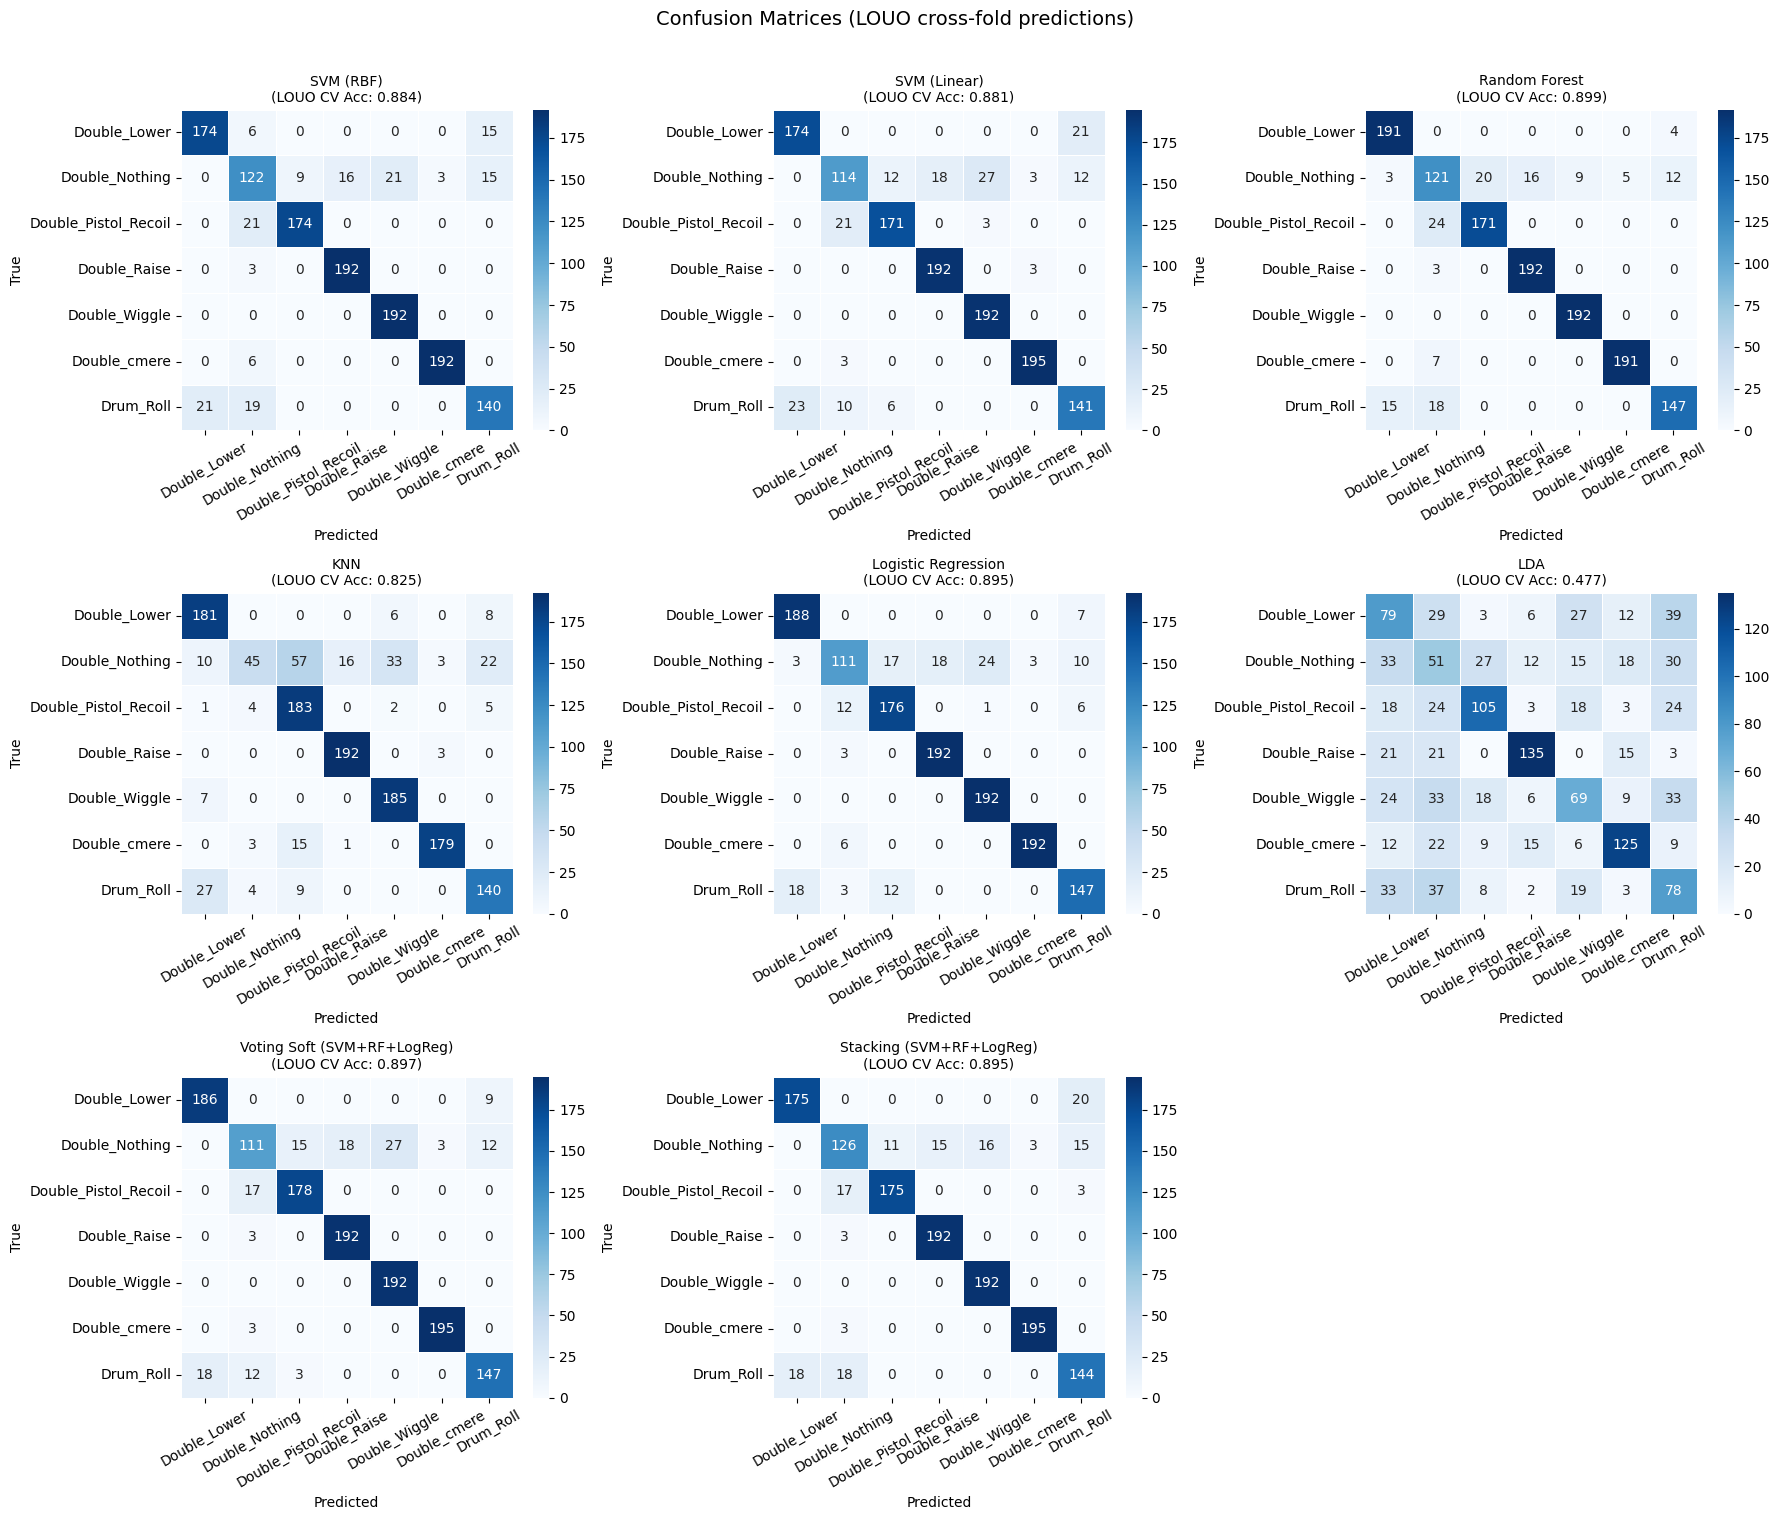

In [21]:
# ── Confusion matrices for all active classifiers (LOUO cross-fold) ──

n_clf = len(results)
ncols = min(3, n_clf)
nrows = (n_clf + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).flatten() if n_clf > 1 else [axes]

short_labels = [lbl.replace('TwoHand_', '').replace('TwoHandDynamic_', 'Dyn_') for lbl in le.classes_]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_train, res['y_pred_cv'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=short_labels, yticklabels=short_labels,
                linewidths=0.5)
    ax.set_title(f'{name}\n(LOUO CV Acc: {res["cv_mean"]:.3f})', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

for ax in axes[n_clf:]:
    ax.set_visible(False)

plt.suptitle('Confusion Matrices (LOUO cross-fold predictions)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


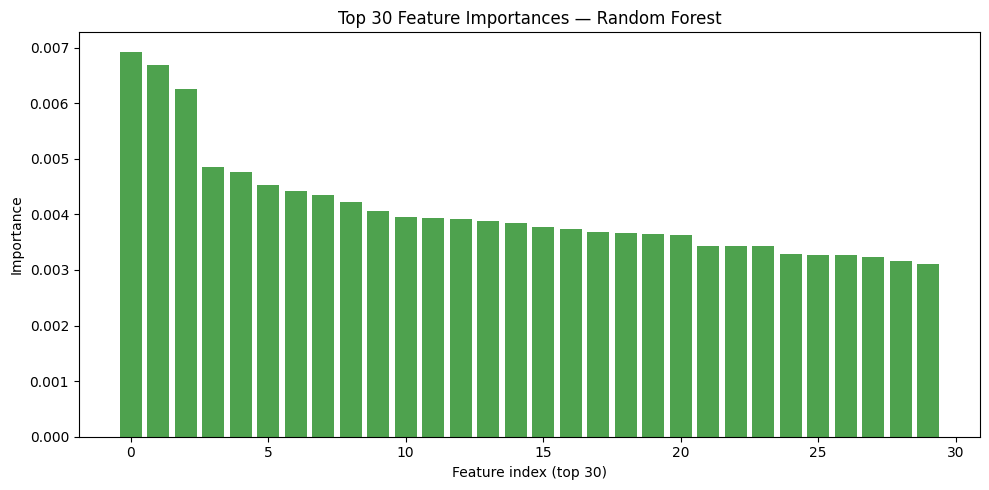

In [22]:
# ── Feature importance (Random Forest) ───────────────────────────────────────

if 'Random Forest' in results:
    rf = results['Random Forest']['clf']
    importances = rf.feature_importances_

    # Map feature indices back to channel names
    n_ch = len(SENSOR_COLS)
    stat_names = ['mean', 'std', 'min', 'max', 'range', 'rms', 'skew', 'kurtosis']

    if FEATURE_MODE == 'stats':
        # importances shape: (8 * n_ch,) — group by channel
        ch_importance = importances.reshape(len(stat_names), n_ch).sum(axis=0)
        top_n = 20
        top_idx = np.argsort(ch_importance)[::-1][:top_n]

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.barh([SENSOR_COLS[i] for i in top_idx[::-1]],
                ch_importance[top_idx[::-1]], color='forestgreen', alpha=0.8)
        ax.set_xlabel('Summed Importance (across stat features)')
        ax.set_title(f'Top {top_n} Most Important Channels — Random Forest')
        plt.tight_layout()
        plt.show()
    else:
        top_n = 30
        top_idx = np.argsort(importances)[::-1][:top_n]
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(range(top_n), importances[top_idx], color='forestgreen', alpha=0.8)
        ax.set_xlabel('Feature index (top 30)')
        ax.set_ylabel('Importance')
        ax.set_title('Top 30 Feature Importances — Random Forest')
        plt.tight_layout()
        plt.show()
else:
    print('Random Forest not enabled — skipping feature importance plot.')

---
## 7. Experiment Log

Use this cell to record what you tried and what worked.

| # | Hands | Segments | Modalities | Feature Mode | Filter | Norm | Best Algorithm | Test Acc | Notes |
|---|-------|----------|------------|--------------|--------|------|----------------|----------|-------|
| 1 | both  | all      | YPR+Flex   | stats        | 5 Hz   | std  |                |          |       |

---
## Notes

**Suggested experiments to try:**

1. **Flex only** — Set `USE_YAW_PITCH_ROLL=False`, `USE_ACCELEROMETER=False`, `USE_FLEX_SENSORS=True`. See if flex alone is sufficient for static gestures.
2. **IMU only** — Opposite: disable flex, keep YPR + accel.
3. **Single hand** — Set `INCLUDE_HANDS=['left']` vs `['right']` to check hand asymmetry.
4. **FFT features** — Change `FEATURE_MODE='fft'` — useful for dynamic gestures (Flapping).
5. **No filter** — Set `APPLY_BUTTERWORTH=False` to see noise impact.
6. **Quaternion channels** — For `TwoHand_L_Flat_R_Flat`, enable `USE_QUATERNIONS=True` and disable YPR.
7. **Wrist only** — Reduce `INCLUDE_SEGMENTS=['wrist']` — minimal sensor configuration.

---
## 8. Manual Sample Testing

Load one or more CSV files and run them through the **exact same preprocessing pipeline** used during training, then predict with all trained classifiers.

Use this to:
- Test a freshly recorded trial that was **not in the training set**
- Verify real-world generalisation
- Diagnose which gestures are being confused

> **Prerequisite:** Run all cells above first (Sections 1–4) so the classifiers, scaler, and pipeline are in memory.

In [23]:
# =============================================================================
# 7B. PREPROCESS + PREDICT
# =============================================================================

def preprocess_sample(fpath, sensor_cols, resample_n, apply_butter, cutoff, order, fs):
    """Load a single CSV and apply the same preprocessing as training."""
    if not os.path.isfile(fpath):
        raise FileNotFoundError(f'File not found: {fpath}')

    df = pd.read_csv(fpath)

    # Select sensor columns (only those available in this file)
    available = [c for c in sensor_cols if c in df.columns]
    missing   = [c for c in sensor_cols if c not in df.columns]
    if missing:
        print(f'  NOTE: {len(missing)} expected columns not found in this file (will be zero-filled):')
        print(f'    {missing[:5]}{" ..." if len(missing) > 5 else ""}')

    # Build array, zero-fill missing columns
    data = np.zeros((len(df), len(sensor_cols)), dtype=np.float32)
    for i, col in enumerate(sensor_cols):
        if col in df.columns:
            data[:, i] = df[col].values.astype(np.float32)

    # Resample
    if resample_n is not None:
        data = resample_trial(data, resample_n)

    # Butterworth filter
    if apply_butter:
        data = apply_butterworth([data], cutoff, order, fs)[0]

    return data


def predict_sample(data, feature_mode, fs, scaler, classifiers):
    """Extract features and predict with all trained classifiers."""
    # Feature extraction
    if feature_mode == 'flatten':
        feats = data.flatten()
    elif feature_mode == 'stats':
        feats = extract_stats(data)
    elif feature_mode == 'fft':
        feats = extract_fft(data, fs)
    elif feature_mode == 'stats+fft':
        feats = np.concatenate([extract_stats(data), extract_fft(data, fs)])

    feats = np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)
    feats_scaled = scaler.transform(feats.reshape(1, -1))  # apply same scaler as training

    predictions = {}
    for name, res in classifiers.items():
        clf = res['clf']
        pred_idx = clf.predict(feats_scaled)[0]
        pred_label = le.inverse_transform([pred_idx])[0]
        # Confidence (probability) if supported
        if hasattr(clf, 'predict_proba'):
            proba = clf.predict_proba(feats_scaled)[0]
            confidence = proba.max()
        elif hasattr(clf, 'decision_function'):
            df_vals = clf.decision_function(feats_scaled)[0]
            if df_vals.ndim == 0:
                confidence = float(abs(df_vals))
            else:
                confidence = float(abs(df_vals).max())
        else:
            confidence = None
        predictions[name] = (pred_label, confidence)

    return predictions


# ── Run prediction on each test sample ───────────────────────────────────────
# print('=' * 70)
# for sample in TEST_SAMPLES:
#     fpath      = sample['path']
#     true_label = sample.get('label', None)

#     print(f'\nFile: {os.path.basename(fpath)}')
#     print(f'True label: {true_label if true_label else "unknown"}')
#     print('-' * 50)

#     try:
#         data = preprocess_sample(
#             fpath        = fpath,
#             sensor_cols  = SENSOR_COLS,
#             resample_n   = RESAMPLE_TO_N_STEPS,
#             apply_butter = APPLY_BUTTERWORTH,
#             cutoff       = BUTTERWORTH_CUTOFF,
#             order        = BUTTERWORTH_ORDER,
#             fs           = SAMPLING_RATE_HZ,
#         )

#         preds = predict_sample(
#             data         = data,
#             feature_mode = FEATURE_MODE,
#             fs           = SAMPLING_RATE_HZ,
#             scaler       = scaler,
#             classifiers  = results,
#         )

#         for clf_name, (pred, conf) in preds.items():
#             correct = '✓' if (true_label and pred == true_label) else ('✗' if true_label else '')
#             conf_str = f'{conf:.3f}' if conf is not None else 'N/A'
#             print(f'  {clf_name:<22} →  {pred:<35} conf={conf_str}  {correct}')

#     except Exception as e:
#         print(f'  ERROR: {e}')

# print('\n' + '=' * 70)

## Test

## 16. Export PDF report (parameters, paths, results)

Builds a compact PDF summarising the data locations, sensor selection, preprocessing,
augmentation, per-classifier CV/hold-out test results, and the external-test performance.
Each run writes a new file — name format: `static_report_<YYYY-MM-DD_HH-MM-SS>_<sig12>.pdf`.


In [24]:
import hashlib, json
from datetime import datetime
from pathlib import Path

from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import mm
from reportlab.lib import colors
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image, PageBreak
)
from reportlab.lib.enums import TA_LEFT



def _fmt(v, nd=4):
    if v is None:
        return '—'
    if isinstance(v, float):
        return f'{v:.{nd}f}'
    return str(v)


_VAL_STYLE = ParagraphStyle('KVValue', fontName='Helvetica', fontSize=7.5, leading=9.5,
                            textColor=colors.HexColor('#222222'))
_KEY_STYLE = ParagraphStyle('KVKey',   fontName='Helvetica-Bold', fontSize=7.5, leading=9.5,
                            textColor=colors.HexColor('#333333'))
_CELL_STYLE = ParagraphStyle('Cell',   fontName='Helvetica', fontSize=7, leading=8.5)
_CELL_BOLD  = ParagraphStyle('CellB',  fontName='Helvetica-Bold', fontSize=7, leading=8.5)


def _wrap(text, style=_VAL_STYLE):
    if isinstance(text, Paragraph):
        return text
    s = str(text).replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')
    return Paragraph(s, style)


def _short_name(name):
    """Return a compact, line-break-friendly label for table headers.
    Long ensemble names like 'Voting Soft (SVM+RF+KNN+LogReg)' are abbreviated;
    other names get '+' replaced with ' + ' so they wrap cleanly."""
    aliases = {
        'Voting Soft (SVM+RF+KNN+LogReg)': 'Voting (soft)',
        'Stacking (SVM+RF+KNN+LogReg)':    'Stacking',
    }
    if name in aliases:
        return aliases[name]
    # Insert spaces around '+' so wrap points exist
    return name.replace('+', ' + ')


def _kv_table(rows, col_widths=(50*mm, 135*mm)):
    wrapped = [[_wrap(r[0], _KEY_STYLE), _wrap(r[1], _VAL_STYLE)] for r in rows]
    tbl = Table(wrapped, colWidths=col_widths, hAlign='LEFT')
    tbl.setStyle(TableStyle([
        ('VALIGN',       (0, 0), (-1, -1), 'TOP'),
        ('BOTTOMPADDING',(0, 0), (-1, -1), 1),
        ('TOPPADDING',   (0, 0), (-1, -1), 1),
        ('LINEBELOW',    (0, 0), (-1, -2), 0.25, colors.HexColor('#dddddd')),
    ]))
    return tbl


def _section(title, styles):
    return Paragraph(f'<b>{title}</b>', styles['Section'])


def _grid_table(rows, col_widths, highlight_last=False, font_size=7):
    """Full-grid table with header row styling and optional last-row highlight."""
    tbl = Table(rows, colWidths=col_widths, hAlign='LEFT')
    style_cmds = [
        ('FONT',         (0, 0), (-1, -1), 'Helvetica',     font_size),
        ('FONT',         (0, 0), (-1,  0), 'Helvetica-Bold', font_size),
        ('BACKGROUND',   (0, 0), (-1,  0), colors.HexColor('#eef2f7')),
        ('GRID',         (0, 0), (-1, -1), 0.25, colors.HexColor('#cccccc')),
        ('VALIGN',       (0, 0), (-1, -1), 'MIDDLE'),
        ('ALIGN',        (1, 1), (-1, -1), 'CENTER'),
        ('BOTTOMPADDING',(0, 0), (-1, -1), 1),
        ('TOPPADDING',   (0, 0), (-1, -1), 1),
    ]
    if highlight_last:
        style_cmds += [
            ('FONT',       (0, -1), (-1, -1), 'Helvetica-Bold', font_size),
            ('BACKGROUND', (0, -1), (-1, -1), colors.HexColor('#fff7e0')),
        ]
    tbl.setStyle(TableStyle(style_cmds))
    return tbl


def _build_signature_payload():
    """Stable, hashable summary of config + headline results."""
    payload = {
        'data_paths':   [str(p) for p in (ACTIVE_DATA_PATHS or [])],
        'sensor_cols':  list(SENSOR_COLS),
        'hands':        list(INCLUDE_HANDS),
        'segments':     list(INCLUDE_SEGMENTS),
        'modalities':   {
            'ypr': bool(USE_YAW_PITCH_ROLL),
            'quat': bool(USE_QUATERNIONS),
            'accel': bool(USE_ACCELEROMETER),
            'flex': bool(USE_FLEX_SENSORS),
        },
        'preprocessing': {
            'resample_n': RESAMPLE_TO_N_STEPS,
            'butterworth': bool(APPLY_BUTTERWORTH),
            'cutoff': BUTTERWORTH_CUTOFF,
            'order': BUTTERWORTH_ORDER,
            'fs': SAMPLING_RATE_HZ,
            'normalisation': NORMALISATION,
            'feature_mode': FEATURE_MODE,
        },
        'augmentation': {
            'enabled': bool(APPLY_AUGMENTATION),
            'n_aug_per_train_trial': int(N_AUG_PER_TRAIN_TRIAL),
            'jitter': bool(AUG_USE_JITTER),
            'jitter_sigma': AUG_JITTER_SIGMA,
            'scale': bool(AUG_USE_SCALE),
            'scale_range': list(AUG_SCALE_RANGE),
            'time_warp': bool(AUG_USE_TIME_WARP),
            'warp_range': list(AUG_WARP_RANGE),
        },
        'split': {'method': 'LOUO (true, all users as folds)', 'n_louo_folds': int(len(np.unique(groups_train))), 'random_state': RANDOM_STATE},
        'classifiers': sorted([k for k, on in ALGORITHMS.items() if on]),
        'classes': list(le.classes_),
        'results': {name: {'cv_mean': float(r['cv_mean']),
                            'cv_std':  float(r['cv_std']),
                            'cv_min': float(min(r['cv_per_fold'])),
                            'cv_max': float(max(r['cv_per_fold']))}
                    for name, r in results.items()},
    }
    return payload


def export_static_report_pdf(out_path):
    styles = getSampleStyleSheet()
    styles.add(ParagraphStyle(name='Section',
                              parent=styles['Heading2'],
                              fontSize=10, spaceBefore=4, spaceAfter=1,
                              textColor=colors.HexColor('#1a3a6c')))
    styles.add(ParagraphStyle(name='Small',
                              parent=styles['BodyText'],
                              fontSize=8, leading=10))
    styles['Title'].fontSize = 14
    styles['Title'].spaceAfter = 4
    styles['Title'].alignment = TA_LEFT

    doc = SimpleDocTemplate(
        str(out_path), pagesize=A4,
        leftMargin=12*mm, rightMargin=12*mm,
        topMargin=10*mm, bottomMargin=10*mm,
        title='Static Gesture Run Report',
    )
    story = []

    # ── Header ───────────────────────────────────────────────────────────────
    story.append(Paragraph('Static Gesture Classification — Run Report', styles['Title']))
    story.append(Paragraph(
        f"Generated {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", styles['Small']))
    story.append(Spacer(1, 4))

    # ── Data paths ───────────────────────────────────────────────────────────
    story.append(_section('Data paths', styles))

    # Per-source trial counts.
    # `source_info` from the loader stores each trial's *gesture-label* folder
    # (e.g. .../Alan/Static/Double_Okay). Aggregate up to the configured
    # training root (e.g. .../Alan/Static) so counts match ACTIVE_DATA_PATHS.
    _paths = list(ACTIVE_DATA_PATHS or [])
    _resolved_paths = [os.path.expanduser(p) for p in _paths]
    _src_counts = {p: 0 for p in _resolved_paths}
    try:
        for _label_folder in source_info:
            _lf = os.path.expanduser(_label_folder)
            # Match the longest configured path that this label folder lives under
            _best = None
            for _rp in _resolved_paths:
                if (_lf == _rp or _lf.startswith(_rp.rstrip(os.sep) + os.sep)) \
                        and (_best is None or len(_rp) > len(_best)):
                    _best = _rp
            if _best is not None:
                _src_counts[_best] += 1
    except NameError:
        _src_counts = {}

    if _paths:
        dp_rows = [[f'Training data path {i+1}',
                    f'{p}'
                    + (f'  \u00b7  {_src_counts.get(os.path.expanduser(p), 0)} trials'
                       if _src_counts else '')]
                   for i, p in enumerate(_paths)]
        dp_rows.append(['Total training paths',
                        f'{len(_paths)}  \u00b7  '
                        f'{sum(_src_counts.values()) if _src_counts else 0} trials total'])
    else:
        dp_rows = [['Training data path', '(none configured)']]

    dp_rows += [
        ['Report output dir',  str(REPORT_OUTPUT_DIR.resolve())],
    ]
    story.append(_kv_table(dp_rows))

    # ── Sensor selection ─────────────────────────────────────────────────────
    story.append(_section('Sensor selection', styles))
    feats = ', '.join([f for f, on in [
        ('YPR', USE_YAW_PITCH_ROLL), ('Quaternion', USE_QUATERNIONS),
        ('Accel', USE_ACCELEROMETER), ('Flex', USE_FLEX_SENSORS),
    ] if on]) or 'none'
    story.append(_kv_table([
        ['Hands',     ', '.join(INCLUDE_HANDS) or 'none'],
        ['Segments',  ', '.join(INCLUDE_SEGMENTS) or 'none'],
        ['Modalities', feats],
        ['Sensor columns', f'{len(SENSOR_COLS)} channels'],
        ['Classes', f'{len(le.classes_)}: ' + ', '.join(le.classes_)],
    ]))

    # ── Preprocessing & split ────────────────────────────────────────────────
    story.append(_section('Preprocessing, features & split', styles))
    story.append(_kv_table([
        ['Resample steps',  str(RESAMPLE_TO_N_STEPS)],
        ['Butterworth',
         f'{"on" if APPLY_BUTTERWORTH else "off"} · cutoff {BUTTERWORTH_CUTOFF} Hz · '
         f'order {BUTTERWORTH_ORDER} · fs {SAMPLING_RATE_HZ} Hz'],
        ['Normalisation',   str(NORMALISATION)],
        ['Feature mode',    f'{FEATURE_MODE} → feature dim {X_train.shape[1]}'],
        ['Split / seed / CV',
         f'random_state={RANDOM_STATE} · CV: LOUO ({len(np.unique(groups_train))} folds, every user held out once)'],
        ['Sample counts',
         f'train (post-aug)={X_train.shape[0]} · LOUO-evaluated samples={X_train.shape[0]}'],
    ]))

    # ── Augmentation ─────────────────────────────────────────────────────────
    story.append(_section('Augmentation (training only)', styles))
    aug_rows = [
        ['Enabled',                'yes' if APPLY_AUGMENTATION else 'no'],
        ['Copies per train trial', str(N_AUG_PER_TRAIN_TRIAL)],
        ['Jitter',
         f'{"on" if AUG_USE_JITTER else "off"} · sigma={AUG_JITTER_SIGMA}'],
        ['Amplitude scale',
         f'{"on" if AUG_USE_SCALE else "off"} · range={AUG_SCALE_RANGE}'],
        ['Time warp',
         f'{"on" if AUG_USE_TIME_WARP else "off"} · range={AUG_WARP_RANGE}'],
    ]
    story.append(_kv_table(aug_rows))

    # ── Classifier results (LOUO CV) ──────────────────────────────────
    story.append(_section('Classifiers — LOUO cross-validation', styles))
    sorted_names = sorted(results.keys(),
                          key=lambda n: results[n]['cv_mean'], reverse=True)
    n_louo_folds = int(len(np.unique(groups_train)))
    res_header = ['Algorithm', f'CV mean (LOUO, {n_louo_folds} folds)',
                  'CV std', 'CV min', 'CV max']
    res_rows = [res_header]
    for name in sorted_names:
        r = results[name]
        cv_folds = np.asarray(r['cv_per_fold'], dtype=float)
        res_rows.append([
            _wrap(name, _CELL_STYLE),
            _fmt(r['cv_mean']),
            _fmt(r['cv_std']),
            _fmt(float(cv_folds.min())),
            _fmt(float(cv_folds.max())),
        ])
    story.append(_grid_table(res_rows,
                             col_widths=(56*mm, 42*mm, 28*mm, 28*mm, 28*mm),
                             font_size=7.5))

    # ── Per-class CV F1 (using cross-fold predictions) ────────────────────
    story.append(_section('Per-class CV F1 (across all LOUO folds)', styles))
    per_class_f1 = {}
    for name in sorted_names:
        rep = classification_report(
            y_train, results[name]['y_pred_cv'],
            target_names=le.classes_, output_dict=True, zero_division=0,
        )
        per_class_f1[name] = {cls: rep[cls]['f1-score'] for cls in le.classes_}

    f1_header = [_wrap('Class', _CELL_BOLD)] \
        + [_wrap(_short_name(n), _CELL_BOLD) for n in sorted_names] \
        + [_wrap('Support', _CELL_BOLD)]
    f1_rows = [f1_header]
    rep_any = classification_report(
        y_train, results[sorted_names[0]]['y_pred_cv'],
        target_names=le.classes_, output_dict=True, zero_division=0,
    )
    for cls in le.classes_:
        row = [_wrap(cls, _CELL_STYLE)]
        for name in sorted_names:
            row.append(_fmt(per_class_f1[name][cls], 3))
        row.append(int(rep_any[cls]['support']))
        f1_rows.append(row)
    macro_row = [_wrap('macro avg', _CELL_BOLD)]
    for name in sorted_names:
        rep = classification_report(
            y_train, results[name]['y_pred_cv'],
            target_names=le.classes_, output_dict=True, zero_division=0,
        )
        macro_row.append(_fmt(rep['macro avg']['f1-score'], 3))
    macro_row.append(int(rep_any['macro avg']['support']))
    f1_rows.append(macro_row)

    n_alg = len(sorted_names)
    cls_w = 50 * mm
    sup_w = 16 * mm
    rem   = 186 * mm - cls_w - sup_w
    alg_w = rem / max(n_alg, 1)
    f1_widths = [cls_w] + [alg_w] * n_alg + [sup_w]
    story.append(_grid_table(f1_rows, col_widths=f1_widths,
                             highlight_last=True, font_size=6.5))

    # ── Per-user accuracy (each user as held-out LOUO fold) ───────────────
    story.append(_section('Per-user accuracy (each user as held-out fold)', styles))
    # Stable user order: numeric prefix if available, else alphabetical
    def _user_key(u):
        s = str(u)
        head = s.split('_')[0]
        return (0, int(head)) if head.isdigit() else (1, s)
    user_order = sorted(results[sorted_names[0]]['per_user'].keys(), key=_user_key)

    pu_header = [_wrap('User', _CELL_BOLD), _wrap('n trials', _CELL_BOLD)] \
        + [_wrap(_short_name(n), _CELL_BOLD) for n in sorted_names]
    pu_rows = [pu_header]
    for u in user_order:
        row = [_wrap(str(u), _CELL_STYLE),
               int(results[sorted_names[0]]['per_user'][u]['n_trials'])]
        for name in sorted_names:
            row.append(_fmt(results[name]['per_user'][u]['accuracy'], 3))
        pu_rows.append(row)
    # Footer: mean ± std across users
    mean_row = [_wrap('Mean (across users)', _CELL_BOLD), '']
    std_row  = [_wrap('Std (across users)',  _CELL_BOLD), '']
    for name in sorted_names:
        accs = np.array([results[name]['per_user'][u]['accuracy'] for u in user_order])
        mean_row.append(_fmt(float(accs.mean()), 3))
        std_row.append (_fmt(float(accs.std()),  3))
    pu_rows.append(mean_row)
    pu_rows.append(std_row)

    user_w = 38 * mm
    n_w    = 18 * mm
    rem_pu = 186 * mm - user_w - n_w
    alg_w_pu = rem_pu / max(n_alg, 1)
    pu_widths = [user_w, n_w] + [alg_w_pu] * n_alg
    story.append(_grid_table(pu_rows, col_widths=pu_widths,
                             highlight_last=True, font_size=7))

    # ── Appendix: data diagnostic figures ─────────────────────────────────
    _diag_figs = globals().get('diagnostic_figures', [])
    if _diag_figs:
        from reportlab.lib.utils import ImageReader
        story.append(PageBreak())
        story.append(_section('Appendix — Data Diagnostics', styles))
        story.append(Paragraph(
            f'{len(_diag_figs)} figures: pooled across users + one per detected user '
            '(extracted-feature views).',
            styles['Small']))
        story.append(Spacer(1, 4))

        # Fit each figure to the available width, preserving aspect ratio.
        max_w_mm = 180  # page width minus margins
        for caption, png_path in _diag_figs:
            try:
                ir = ImageReader(png_path)
                iw, ih = ir.getSize()
                target_w = max_w_mm * mm
                target_h = target_w * ih / iw
                # Cap the height so it fits on a page (A4 usable ~ 240mm)
                if target_h > 220 * mm:
                    target_h = 220 * mm
                    target_w = target_h * iw / ih
                story.append(Paragraph(f'<b>{caption}</b>', styles['Small']))
                story.append(Spacer(1, 2))
                story.append(Image(png_path, width=target_w, height=target_h))
                story.append(Spacer(1, 6))
            except Exception as _e:
                story.append(Paragraph(
                    f'(Failed to embed {png_path}: {_e})', styles['Small']))

    doc.build(story)
    print(f'PDF report written to {out_path}')
    return out_path


# Build a unique filename so re-running this cell never overwrites a previous report.
# Format: static_report_<YYYY-MM-DD_HH-MM-SS>_<sig12>.pdf — the 12-char signature is a
# SHA-256 of the current config + headline results (timestamp excluded), so identical
# re-runs produce the same signature while the timestamp keeps filenames unique.
_payload = _build_signature_payload()
_signature = hashlib.sha256(
    json.dumps(_payload, sort_keys=True, default=str).encode()
).hexdigest()[:12]
_timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
_report_filename = f'static_report_{_timestamp}_{_signature}.pdf'

report_pdf_path = export_static_report_pdf(REPORT_OUTPUT_DIR / _report_filename)


PDF report written to /home/jestin/ThesisRepo/ML/NewReports/StaticReports/static_report_2026-05-14_13-11-18_e12c65163b3a.pdf


## 11. Completion notification

Fires whichever channels you enabled in Section 1C of the config so you can walk away during the run.

- **`NOTIFY_DESKTOP`** — Ubuntu toast (`notify-send`). Needs `libnotify-bin`, installed by default on most desktops.
- **`NOTIFY_BEEP`** — short system bell from inside the notebook.
- **`NOTIFY_PUSH`** — off-device push via [ntfy.sh](https://ntfy.sh) (free, no signup). Install the ntfy app on your phone, subscribe to `NOTIFY_NTFY_TOPIC`, and you'll get a push the moment the run finishes. The topic acts like a password — pick something long and hard to guess.

The body includes the LOUO mean accuracy for each active classifier so you know the result before reopening the notebook. Each channel fails open: if it can't reach the desktop / network / speaker it prints a warning and the next channel still runs.


In [25]:
# ============================================================================
#  Section 11 — Completion notification
# ============================================================================
# Build the message body from the `results` dict the training cell populated.
_summary_lines = ['LOUO complete.']
try:
    _ranked = sorted(results.items(), key=lambda kv: -kv[1]['cv_mean'])
    for _name, _r in _ranked:
        _summary_lines.append(
            f"  {_name}: {_r['cv_mean']:.4f} \u00b1 {_r['cv_std']:.4f} "
            f"(min {min(_r['cv_per_fold']):.3f}, max {max(_r['cv_per_fold']):.3f})"
        )
except NameError:
    _summary_lines.append('  (no `results` dict available — did the training cell run?)')

_notify_title = 'Glove gesture LOUO run'
_notify_body  = '\n'.join(_summary_lines)
print(_notify_body)


# ── Channel 1: Ubuntu desktop toast via notify-send ──────────────────────────
if NOTIFY_DESKTOP:
    import shutil, subprocess
    if shutil.which('notify-send'):
        try:
            subprocess.run(
                ['notify-send', '--app-name=Jupyter',
                 '--icon=dialog-information', '--urgency=normal',
                 _notify_title, _notify_body],
                check=False,
            )
            print('Desktop notification sent.')
        except Exception as _e:
            print(f'Desktop notification failed: {_e}')
    else:
        print('Desktop notification skipped: notify-send not on PATH '
              '(install with `sudo apt install libnotify-bin`).')


# ── Channel 2: audible bell ──────────────────────────────────────────────
if NOTIFY_BEEP:
    try:
        import sys, time
        for _ in range(3):
            sys.stdout.write('\a')
            sys.stdout.flush()
            time.sleep(0.20)
        print('Beep sent.')
    except Exception as _e:
        print(f'Beep failed: {_e}')


# ── Channel 3: off-device push via ntfy.sh ───────────────────────────────────
if NOTIFY_PUSH:
    try:
        import urllib.request
        if 'CHANGE-ME' in NOTIFY_NTFY_TOPIC:
            print('Push notification skipped: set NOTIFY_NTFY_TOPIC '
                  'in Section 1C of the config first.')
        else:
            req = urllib.request.Request(
                f'https://ntfy.sh/{NOTIFY_NTFY_TOPIC}',
                data=_notify_body.encode('utf-8'),
                headers={
                    'Title':    _notify_title,
                    'Priority': 'default',
                    'Tags':     'white_check_mark',
                },
                method='POST',
            )
            with urllib.request.urlopen(req, timeout=10) as _r:
                _ = _r.read()
            print(f'Push notification sent to ntfy topic {NOTIFY_NTFY_TOPIC!r}.')
    except Exception as _e:
        print(f'Push notification failed: {_e}')


LOUO complete.
  Random Forest: 0.8988 ± 0.0805 (min 0.724, max 1.000)
  Voting Soft (SVM+RF+LogReg): 0.8970 ± 0.0887 (min 0.657, max 0.972)
  Stacking (SVM+RF+LogReg): 0.8954 ± 0.0901 (min 0.667, max 1.000)
  Logistic Regression: 0.8947 ± 0.0863 (min 0.657, max 0.972)
  SVM (RBF): 0.8840 ± 0.0828 (min 0.657, max 0.972)
  SVM (Linear): 0.8809 ± 0.0961 (min 0.629, max 0.972)
  KNN: 0.8253 ± 0.0508 (min 0.714, max 0.917)
  LDA: 0.4775 ± 0.1661 (min 0.229, max 0.800)
Desktop notification sent.



(notify-send:1514298): libnotify-WARNING **: 13:11:19.210: Running in confined mode, using Portal notifications. Some features and hints won't be supported
libnotify-Message: 13:11:19.210: Category is not available when using Portal Notifications
libnotify-Message: 13:11:19.210: App Name is not available when using Portal Notifications
